FRED API Key 未設定為環境變數，建議手動設定。
--- 正在從 FRED 獲取 DGS2 數據 (2000-01-01 至 2024-08-31) ---

歷史 Context 總長度: 6044 天 (從 2000 年至今)
預測 Horizon 長度: 127 天
正在配置 TimesFM 參數物件...
正在初始化 TimesFm (Context: 512, Horizon: 127)...


Fetching 3 files: 100%|██████████| 3/3 [00:00<?, ?it/s]


模型初始化成功！開始執行預測...

========== 6 個月預測誤差結果 ==========
預測區間: 2024-03-01 至 2024-08-31
平均絕對誤差 (MAE): 0.35934
均方根誤差 (RMSE): 0.43139


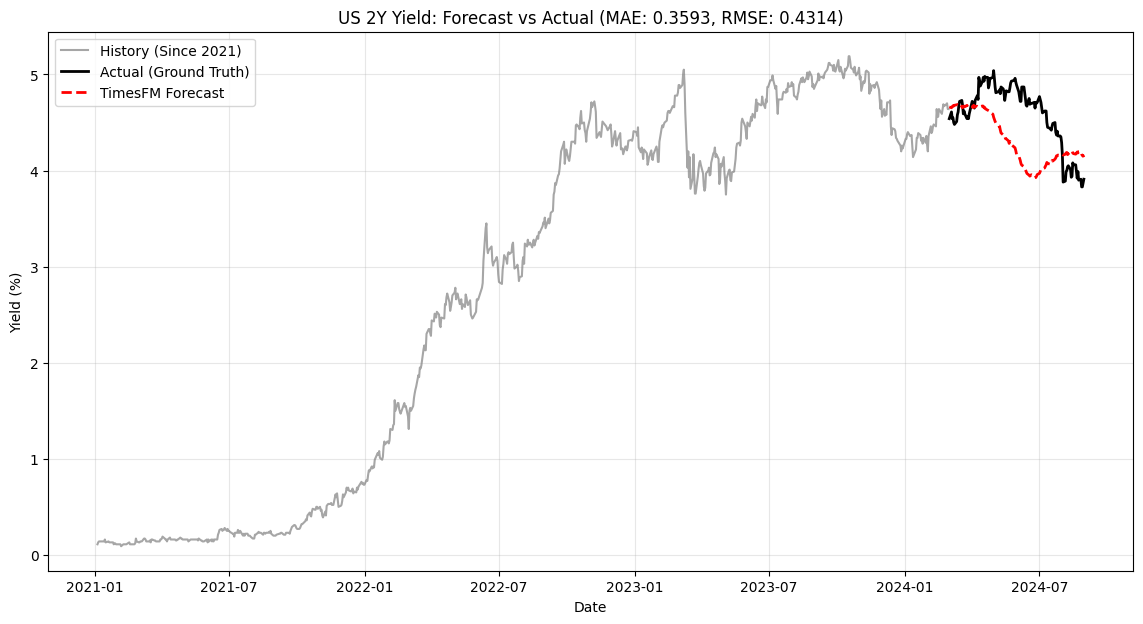

In [7]:
import pandas as pd
import numpy as np
import torch
import os
import timesfm
from pandas_datareader import data as pdr
import matplotlib.pyplot as plt

# --- 1. 設定參數與數據獲取 ---
FRED_API_KEY = os.environ.get('FRED_API_KEY') 
if not FRED_API_KEY:
    print("FRED API Key 未設定為環境變數，建議手動設定。")

TICKER = 'DGS2' 

# 預測區間：預測 2024 年 3 月至 8 月 (6個月)
PREDICTION_START = '2024-03-01'
END_DATE = '2024-08-31' 

# [修改點] 將歷史數據拉長至 2000 年
START_DATE = '2000-01-01' 

def fetch_and_prepare_data(ticker, start, end):
    print(f"--- 正在從 FRED 獲取 {ticker} 數據 ({start} 至 {end}) ---")
    try:
        data = pdr.get_data_fred(ticker, start=start, end=end)
        data = data.dropna()
        data[ticker] = pd.to_numeric(data[ticker], errors='coerce')
        return data[ticker].squeeze()
    except Exception as e:
        print(f"數據獲取失敗: {e}")
        return None

# --- 2. 數據獲取與劃分 ---
yield_series = fetch_and_prepare_data(TICKER, START_DATE, END_DATE)

if yield_series is not None and not yield_series.empty:
    
    # 歷史 Context
    context_series = yield_series.loc[:PREDICTION_START].iloc[:-1] 
    # 實際驗證值
    actual_series = yield_series.loc[PREDICTION_START:END_DATE]
    
    context_array = context_series.values.astype(np.float32)
    actual_values = actual_series.values
    
    horizon_length = len(actual_series)
    print(f"\n歷史 Context 總長度: {len(context_array)} 天 (從 2000 年至今)")
    print(f"預測 Horizon 長度: {horizon_length} 天")
    
   # --- 3. TimesFM 模型預測 (修正 Repo ID 版) ---
   # --- 3. TimesFM 模型預測 (修正 forecast 呼叫版) ---
    try:
        print("正在配置 TimesFM 參數物件...")
        
        # 1. 建立 Hparams 物件
        hparams = timesfm.TimesFmHparams(
            backend='gpu',
            context_len=512,        
            horizon_len=horizon_length, # <--- 這裡設定過長度了，模型已經記住了
            input_patch_len=32,     
            output_patch_len=128,   
            num_layers=20,          
            model_dims=1280         
        )
        
        # 2. 建立 Checkpoint 物件
        checkpoint = timesfm.TimesFmCheckpoint(
            huggingface_repo_id="google/timesfm-1.0-200m-pytorch"
        )
        
        print(f"正在初始化 TimesFm (Context: 512, Horizon: {horizon_length})...")
        # 這次不用下載了，會直接讀取剛剛下載好的快取檔案
        
        # 3. 將這兩個物件傳入 TimesFm
        tfm = timesfm.TimesFm(hparams=hparams, checkpoint=checkpoint)
        
        print("模型初始化成功！開始執行預測...")
        
        # [修正點] 執行預測：只傳入 inputs，不傳 horizon
        point_forecast, _ = tfm.forecast(
            inputs=[context_array]
        )
        predicted_values = point_forecast[0]

        # --- 4. 誤差計算 ---
        mae = np.mean(np.abs(predicted_values - actual_values))
        rmse = np.sqrt(np.mean((predicted_values - actual_values)**2))
        
        print("\n========== 6 個月預測誤差結果 ==========")
        print(f"預測區間: {PREDICTION_START} 至 {END_DATE}")
        print(f"平均絕對誤差 (MAE): {mae:.5f}")
        print(f"均方根誤差 (RMSE): {rmse:.5f}")
        print("========================================")

        # --- 5. 視覺化 ---
        import matplotlib.pyplot as plt
        plt.figure(figsize=(14, 7))
        
        # 畫出最近 3 年 (2021起)
        plot_start_year = '2021-01-01'
        history_plot = context_series.loc[plot_start_year:]
        
        plt.plot(history_plot.index, history_plot.values, label='History (Since 2021)', color='gray', alpha=0.7)
        plt.plot(actual_series.index, actual_series.values, label='Actual (Ground Truth)', color='black', linewidth=2)
        plt.plot(actual_series.index, predicted_values, label='TimesFM Forecast', color='red', linestyle='--', linewidth=2)
        
        plt.title(f'US 2Y Yield: Forecast vs Actual (MAE: {mae:.4f}, RMSE: {rmse:.4f})')
        plt.xlabel('Date')
        plt.ylabel('Yield (%)')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()
        
    except Exception as e:
        print(f"\n[執行錯誤]: {e}")
        import traceback
        traceback.print_exc() # 印出完整錯誤追蹤，方便除錯

FRED API Key 未設定為環境變數，建議手動設定。
--- 正在從 FRED 獲取 DGS2 數據 (2000-01-01 至 2023-06-30) ---

歷史 Context 結束於: 2022-06-30
預測 Horizon 長度 (1年交易日): 250 天
正在配置 TimesFM 參數物件...
正在初始化 TimesFm (Target: 2022/07 - 2023/06)...


Fetching 3 files: 100%|██████████| 3/3 [00:00<00:00, 5977.63it/s]


模型初始化成功！開始執行預測...

========== 預測誤差結果 (升息循環期間) ==========
預測區間: 2022-07-01 至 2023-06-30
平均絕對誤差 (MAE): 1.28688
均方根誤差 (RMSE): 1.40431


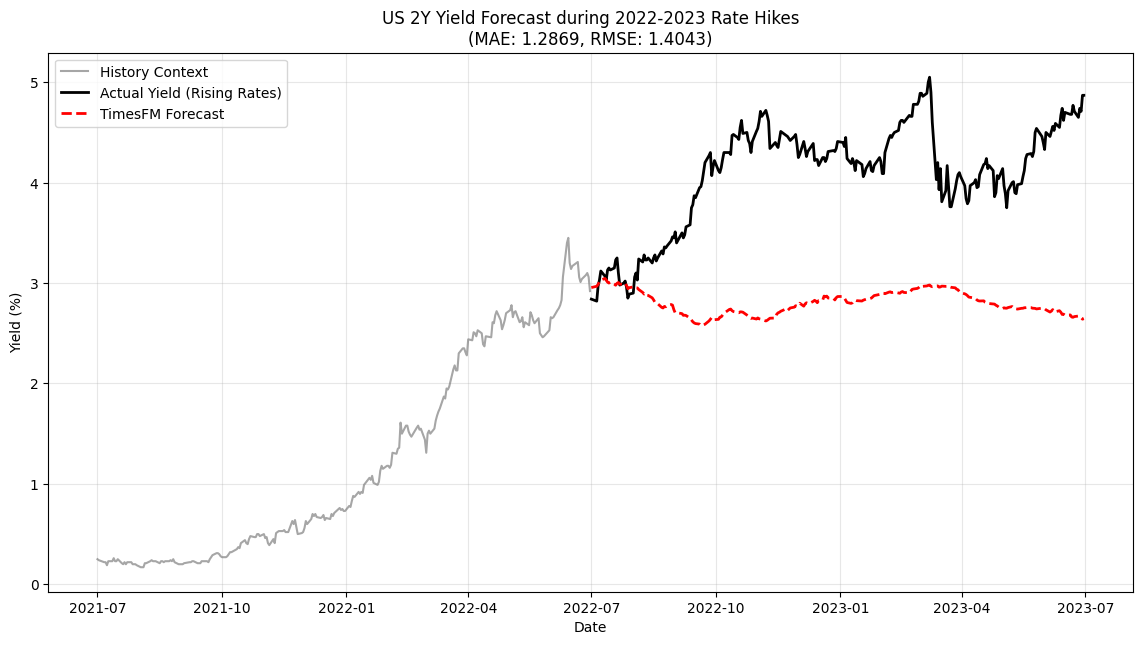

In [8]:
import pandas as pd
import numpy as np
import torch
import os
import timesfm
from pandas_datareader import data as pdr
import matplotlib.pyplot as plt

# --- 1. 設定參數與數據獲取 ---
FRED_API_KEY = os.environ.get('FRED_API_KEY') 
if not FRED_API_KEY:
    print("FRED API Key 未設定為環境變數，建議手動設定。")

TICKER = 'DGS2' 

# [修改點] 設定預測區間：2022年7月起的一整年
PREDICTION_START = '2022-07-01'
END_DATE = '2023-06-30' 

# 歷史數據：保留長歷史
START_DATE = '2000-01-01' 

def fetch_and_prepare_data(ticker, start, end):
    print(f"--- 正在從 FRED 獲取 {ticker} 數據 ({start} 至 {end}) ---")
    try:
        data = pdr.get_data_fred(ticker, start=start, end=end)
        data = data.dropna()
        data[ticker] = pd.to_numeric(data[ticker], errors='coerce')
        return data[ticker].squeeze()
    except Exception as e:
        print(f"數據獲取失敗: {e}")
        return None

# --- 2. 數據獲取與劃分 ---
yield_series = fetch_and_prepare_data(TICKER, START_DATE, END_DATE)

if yield_series is not None and not yield_series.empty:
    
    # 歷史 Context (截止到 2022-06-30)
    context_series = yield_series.loc[:PREDICTION_START].iloc[:-1] 
    # 實際驗證值 (2022-07-01 ~ 2023-06-30)
    actual_series = yield_series.loc[PREDICTION_START:END_DATE]
    
    context_array = context_series.values.astype(np.float32)
    actual_values = actual_series.values
    
    horizon_length = len(actual_series)
    print(f"\n歷史 Context 結束於: {context_series.index[-1].date()}")
    print(f"預測 Horizon 長度 (1年交易日): {horizon_length} 天")
    
    # --- 3. TimesFM 模型預測 ---
    try:
        print("正在配置 TimesFM 參數物件...")
        
        # 1. 建立 Hparams
        # 注意：horizon_len 是動態的，必須設為這次的一年長度
        hparams = timesfm.TimesFmHparams(
            backend='gpu',
            context_len=512,        
            horizon_len=horizon_length, 
            input_patch_len=32,     
            output_patch_len=128,   
            num_layers=20,          
            model_dims=1280         
        )
        
        # 2. 建立 Checkpoint
        checkpoint = timesfm.TimesFmCheckpoint(
            huggingface_repo_id="google/timesfm-1.0-200m-pytorch"
        )
        
        print(f"正在初始化 TimesFm (Target: 2022/07 - 2023/06)...")
        
        # 3. 初始化模型
        tfm = timesfm.TimesFm(hparams=hparams, checkpoint=checkpoint)
        
        print("模型初始化成功！開始執行預測...")
        
        # 4. 執行預測 (無 horizon 參數)
        point_forecast, _ = tfm.forecast(
            inputs=[context_array]
        )
        predicted_values = point_forecast[0]

        # --- 4. 誤差計算 ---
        mae = np.mean(np.abs(predicted_values - actual_values))
        rmse = np.sqrt(np.mean((predicted_values - actual_values)**2))
        
        print("\n========== 預測誤差結果 (升息循環期間) ==========")
        print(f"預測區間: {PREDICTION_START} 至 {END_DATE}")
        print(f"平均絕對誤差 (MAE): {mae:.5f}")
        print(f"均方根誤差 (RMSE): {rmse:.5f}")
        print("=================================================")

        # --- 5. 視覺化 ---
        import matplotlib.pyplot as plt
        plt.figure(figsize=(14, 7))
        
        # 畫出預測前一年的走勢，看看模型是接續著什麼趨勢預測的
        plot_start_year = '2021-07-01'
        history_plot = context_series.loc[plot_start_year:]
        
        plt.plot(history_plot.index, history_plot.values, label='History Context', color='gray', alpha=0.7)
        plt.plot(actual_series.index, actual_series.values, label='Actual Yield (Rising Rates)', color='black', linewidth=2)
        plt.plot(actual_series.index, predicted_values, label='TimesFM Forecast', color='red', linestyle='--', linewidth=2)
        
        plt.title(f'US 2Y Yield Forecast during 2022-2023 Rate Hikes\n(MAE: {mae:.4f}, RMSE: {rmse:.4f})')
        plt.xlabel('Date')
        plt.ylabel('Yield (%)')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()
        
    except Exception as e:
        print(f"\n[執行錯誤]: {e}")
        import traceback
        traceback.print_exc()
else:
    print("\n無法進行預測，數據為空。")

FRED API Key 未設定為環境變數，建議手動設定。
--- 正在從 FRED 獲取 DGS2 數據 (2022-07-01 至 2025-11-15) ---

歷史 Context 區間: 2022-07-01 至 2025-08-28
歷史 Context 長度: 790 天
預測 Horizon 長度 (9月-11月中): 52 天
正在配置 TimesFM 參數物件...
正在初始化 TimesFm...


Fetching 3 files: 100%|██████████| 3/3 [00:00<?, ?it/s]


模型初始化成功！開始執行預測...

========== 2025年秋季預測誤差結果 ==========
預測區間: 2025-09-01 至 2025-11-15
平均絕對誤差 (MAE): 0.08281
均方根誤差 (RMSE): 0.09988


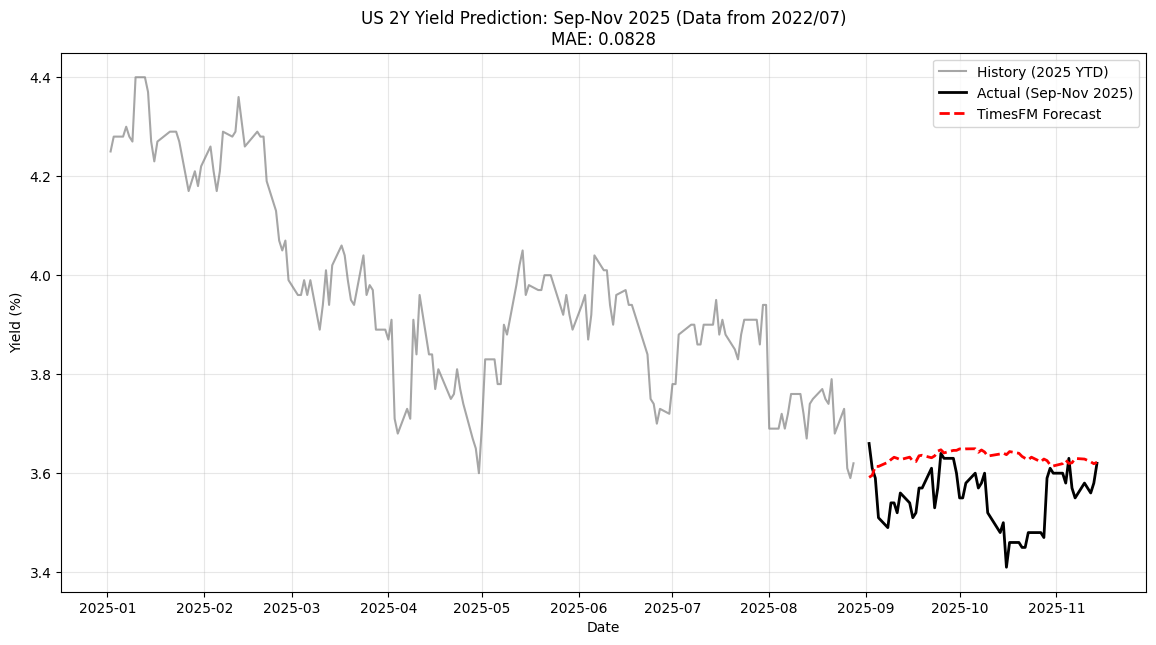

In [10]:
import pandas as pd
import numpy as np
import torch
import os
import timesfm
from pandas_datareader import data as pdr
import matplotlib.pyplot as plt

# --- 1. 設定參數與數據獲取 ---
FRED_API_KEY = os.environ.get('FRED_API_KEY') 
if not FRED_API_KEY:
    print("FRED API Key 未設定為環境變數，建議手動設定。")

TICKER = 'DGS2' 

# [修改點 1] 預測目標區間：2025/09/01 至 2025/11/15
PREDICTION_START = '2025-09-01'
END_DATE = '2025-11-15' 

# [修改點 2] 歷史數據限制：只看 2022/07 以後
# 這意味著模型完全看不到以前的低利率時代數據
START_DATE = '2022-07-01' 

def fetch_and_prepare_data(ticker, start, end):
    print(f"--- 正在從 FRED 獲取 {ticker} 數據 ({start} 至 {end}) ---")
    try:
        data = pdr.get_data_fred(ticker, start=start, end=end)
        data = data.dropna()
        data[ticker] = pd.to_numeric(data[ticker], errors='coerce')
        return data[ticker].squeeze()
    except Exception as e:
        print(f"數據獲取失敗: {e}")
        return None

# --- 2. 數據獲取與劃分 ---
yield_series = fetch_and_prepare_data(TICKER, START_DATE, END_DATE)

if yield_series is not None and not yield_series.empty:
    
    # 歷史 Context (從 2022-07-01 到 2025-08-31)
    context_series = yield_series.loc[:PREDICTION_START].iloc[:-1] 
    # 實際驗證值 (2025-09-01 ~ 2025-11-15)
    actual_series = yield_series.loc[PREDICTION_START:END_DATE]
    
    context_array = context_series.values.astype(np.float32)
    actual_values = actual_series.values
    
    horizon_length = len(actual_series)
    print(f"\n歷史 Context 區間: {context_series.index[0].date()} 至 {context_series.index[-1].date()}")
    print(f"歷史 Context 長度: {len(context_array)} 天")
    print(f"預測 Horizon 長度 (9月-11月中): {horizon_length} 天")
    
    # --- 3. TimesFM 模型預測 ---
    try:
        print("正在配置 TimesFM 參數物件...")
        
        # 1. 建立 Hparams 物件
        # context_len=512 足以涵蓋 2022-2025 這三年的數據 (512交易日約等於2年)
        # 由於我們只給了約 3 年數據，模型會吃到大部分的歷史資訊
        hparams = timesfm.TimesFmHparams(
            backend='gpu',
            context_len=512,        
            horizon_len=horizon_length, 
            input_patch_len=32,     
            output_patch_len=128,   
            num_layers=20,          
            model_dims=1280         
        )
        
        # 2. 建立 Checkpoint 物件
        checkpoint = timesfm.TimesFmCheckpoint(
            huggingface_repo_id="google/timesfm-1.0-200m-pytorch"
        )
        
        print(f"正在初始化 TimesFm...")
        tfm = timesfm.TimesFm(hparams=hparams, checkpoint=checkpoint)
        
        print("模型初始化成功！開始執行預測...")
        
        # 3. 執行預測
        point_forecast, _ = tfm.forecast(
            inputs=[context_array]
        )
        predicted_values = point_forecast[0]

        # --- 4. 誤差計算 ---
        if len(actual_values) > 0:
            mae = np.mean(np.abs(predicted_values - actual_values))
            rmse = np.sqrt(np.mean((predicted_values - actual_values)**2))
            
            print("\n========== 2025年秋季預測誤差結果 ==========")
            print(f"預測區間: {PREDICTION_START} 至 {END_DATE}")
            print(f"平均絕對誤差 (MAE): {mae:.5f}")
            print(f"均方根誤差 (RMSE): {rmse:.5f}")
            print("============================================")

            # --- 5. 視覺化 ---
            import matplotlib.pyplot as plt
            plt.figure(figsize=(14, 7))
            
            # 為了看清楚，畫出 2025 年 1 月以來的走勢
            plot_start_year = '2025-01-01'
            history_plot = context_series.loc[plot_start_year:]
            
            plt.plot(history_plot.index, history_plot.values, label='History (2025 YTD)', color='gray', alpha=0.7)
            plt.plot(actual_series.index, actual_series.values, label='Actual (Sep-Nov 2025)', color='black', linewidth=2)
            plt.plot(actual_series.index, predicted_values, label='TimesFM Forecast', color='red', linestyle='--', linewidth=2)
            
            plt.title(f'US 2Y Yield Prediction: Sep-Nov 2025 (Data from 2022/07)\nMAE: {mae:.4f}')
            plt.xlabel('Date')
            plt.ylabel('Yield (%)')
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.show()
        else:
            print("\n[警告] 無法計算誤差：實際驗證數據為空。")
            print("可能原因：FRED 資料庫尚未更新到 2025 年 11 月的數據，或者今天還沒到那個日期。")
            
    except Exception as e:
        print(f"\n[執行錯誤]: {e}")
        import traceback
        traceback.print_exc()

else:
    print("\n無法進行預測，數據為空或 FRED 無法獲取指定日期的資料。")

FRED API Key 未設定為環境變數，建議手動設定。
--- 正在從 FRED 獲取 DGS2 歷史大數據 (1980-01-01 至今) ---

最新數據日期: 2025-11-18
歷史數據總筆數: 11471 筆 (涵蓋 1980 至今)
準備預測未來: 252 天 (約一年)
正在配置 TimesFM 參數物件...
正在初始化 TimesFm...


Fetching 3 files: 100%|██████████| 3/3 [00:00<?, ?it/s]


模型初始化成功！開始執行未來一年預測...
預測完成！預測區間: 2025-11-19 至 2026-11-05
一年後預測值: 4.40%


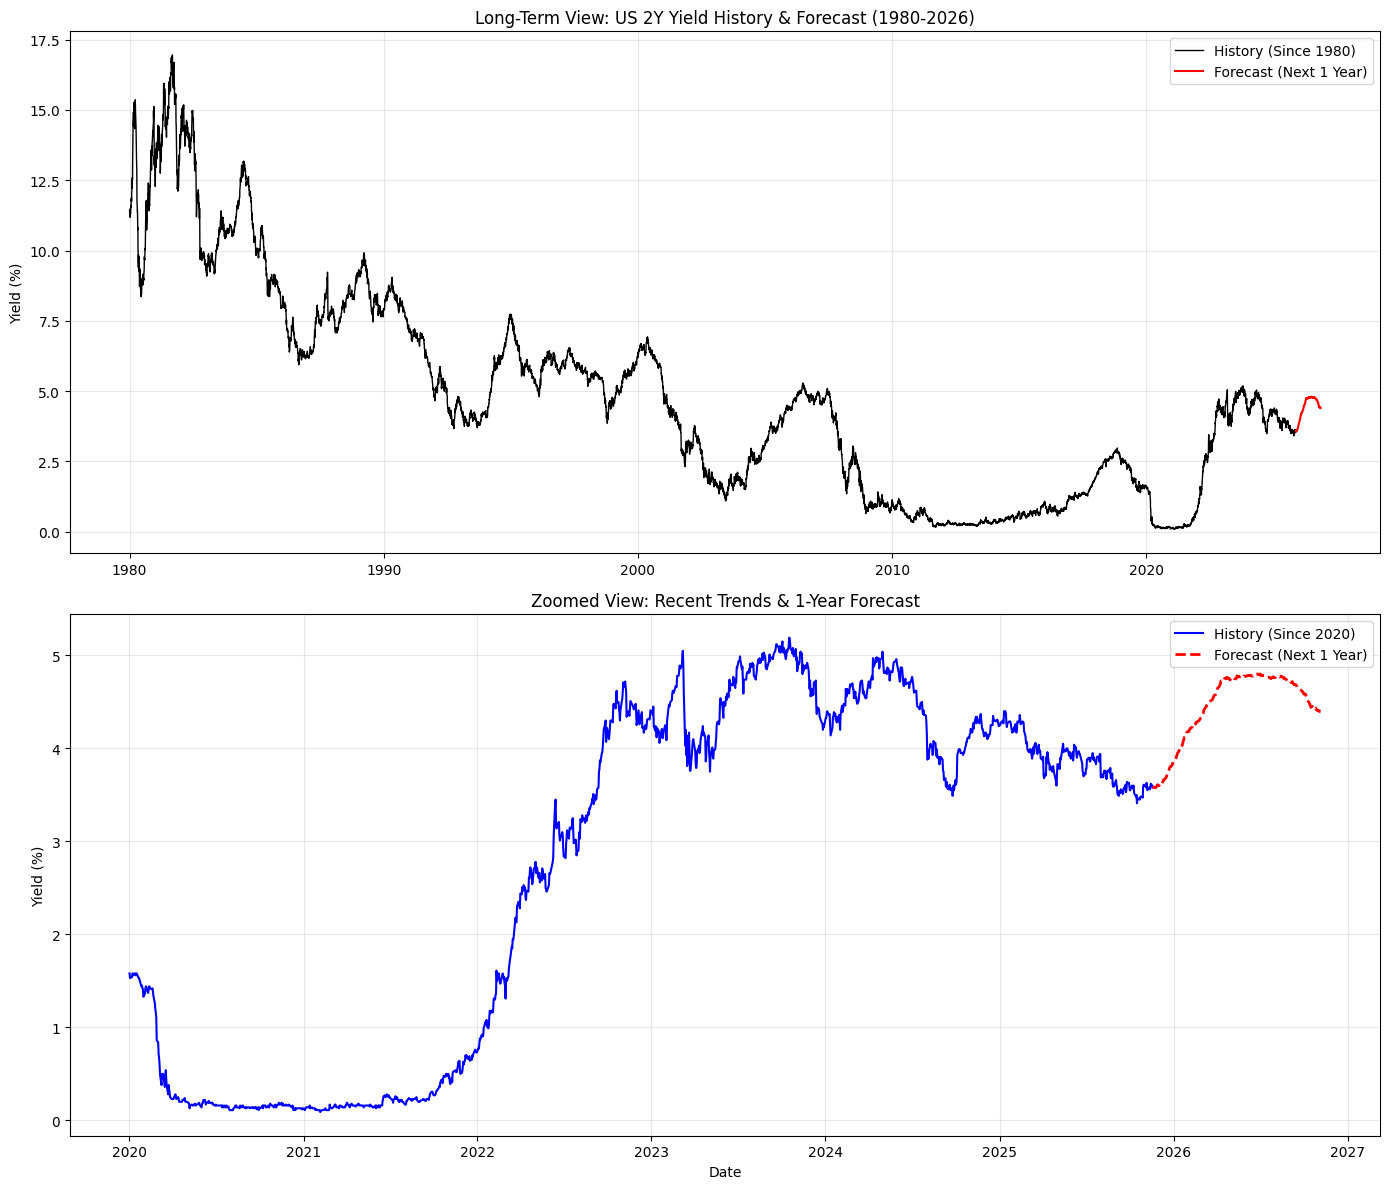

In [11]:
import pandas as pd
import numpy as np
import torch
import os
import timesfm
from pandas_datareader import data as pdr
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

# --- 1. 設定參數 ---
FRED_API_KEY = os.environ.get('FRED_API_KEY') 
if not FRED_API_KEY:
    print("FRED API Key 未設定為環境變數，建議手動設定。")

TICKER = 'DGS2' 

# [修改點 1] 歷史數據回溯至 1980 年
START_DATE = '1980-01-01'

# 獲取截至今日的最新數據
END_DATE = datetime.today().strftime('%Y-%m-%d')

# [修改點 2] 設定預測長度：未來一年 (約 252 個工作日)
HORIZON_LENGTH = 252

def fetch_latest_data(ticker, start):
    print(f"--- 正在從 FRED 獲取 {ticker} 歷史大數據 ({start} 至今) ---")
    try:
        # 抓取 40 多年的數據
        data = pdr.get_data_fred(ticker, start=start)
        data = data.dropna()
        data[ticker] = pd.to_numeric(data[ticker], errors='coerce')
        return data[ticker].squeeze()
    except Exception as e:
        print(f"數據獲取失敗: {e}")
        return None

# --- 2. 數據準備 ---
yield_series = fetch_latest_data(TICKER, START_DATE)

if yield_series is not None and not yield_series.empty:
    
    context_array = yield_series.values.astype(np.float32)
    last_date = yield_series.index[-1]
    
    print(f"\n最新數據日期: {last_date.date()}")
    print(f"歷史數據總筆數: {len(context_array)} 筆 (涵蓋 1980 至今)")
    print(f"準備預測未來: {HORIZON_LENGTH} 天 (約一年)")

    # --- 3. TimesFM 模型預測 ---
    try:
        print("正在配置 TimesFM 參數物件...")
        
        hparams = timesfm.TimesFmHparams(
            backend='gpu',
            context_len=512,        # 模型硬體限制 (雖然給了40年，它主要看最後2年)
            horizon_len=HORIZON_LENGTH, # 設定為 252 天 (一年)
            input_patch_len=32,     
            output_patch_len=128,   
            num_layers=20,          
            model_dims=1280         
        )
        
        checkpoint = timesfm.TimesFmCheckpoint(
            huggingface_repo_id="google/timesfm-1.0-200m-pytorch"
        )
        
        print(f"正在初始化 TimesFm...")
        tfm = timesfm.TimesFm(hparams=hparams, checkpoint=checkpoint)
        
        print("模型初始化成功！開始執行未來一年預測...")
        
        # 執行預測
        point_forecast, _ = tfm.forecast(
            inputs=[context_array]
        )
        forecast_values = point_forecast[0]

        # --- 4. 生成未來的日期軸 ---
        # 從最後一天數據的 "下一天" 開始，生成 252 個工作日
        future_dates = pd.bdate_range(start=last_date + timedelta(days=1), periods=HORIZON_LENGTH)
        
        # 建立預測 Series
        forecast_series = pd.Series(forecast_values, index=future_dates)
        
        print(f"預測完成！預測區間: {future_dates[0].date()} 至 {future_dates[-1].date()}")
        print(f"一年後預測值: {forecast_values[-1]:.2f}%")

        # --- 5. 視覺化 (雙圖表策略) ---
        # 因為 1980 年的數據太長，直接畫會看不清未來一年的細節
        # 我們畫兩張圖：一張全覽，一張近況
        
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))
        
        # 圖一：歷史全覽 (1980 - 2026)
        ax1.plot(yield_series.index, yield_series.values, label='History (Since 1980)', color='black', linewidth=1)
        ax1.plot(forecast_series.index, forecast_series.values, label='Forecast (Next 1 Year)', color='red', linewidth=1.5)
        ax1.set_title(f'Long-Term View: US 2Y Yield History & Forecast (1980-2026)')
        ax1.set_ylabel('Yield (%)')
        ax1.grid(True, alpha=0.3)
        ax1.legend()
        
        # 圖二：近期聚焦 (最近 5 年 + 未來 1 年)
        zoom_start = '2020-01-01'
        recent_history = yield_series.loc[zoom_start:]
        
        ax2.plot(recent_history.index, recent_history.values, label='History (Since 2020)', color='blue', linewidth=1.5)
        ax2.plot(forecast_series.index, forecast_series.values, label='Forecast (Next 1 Year)', color='red', linestyle='--', linewidth=2)
        ax2.set_title(f'Zoomed View: Recent Trends & 1-Year Forecast')
        ax2.set_xlabel('Date')
        ax2.set_ylabel('Yield (%)')
        ax2.grid(True, alpha=0.3)
        ax2.legend()
        
        plt.tight_layout()
        plt.show()
        
    except Exception as e:
        print(f"\n[執行錯誤]: {e}")
        import traceback
        traceback.print_exc()

else:
    print("\n無法進行預測，數據為空。")

C:\Users\user\anaconda3\envs\timesfm\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


--- 下載完整數據 (1970-01-01 - 2025-11-15) ---
數據下載完成。預測目標長度 (Horizon): 148 天

--- 初始化 TimesFM 2.5 (GPU: NVIDIA GeForce RTX 5060 Ti) ---
Downloaded.
正在編譯模型設定 (Compile)...
模型載入成功！開始極速運算...



GPU 運算中: 100%|██████████| 12/12 [00:09<00:00,  1.24it/s]


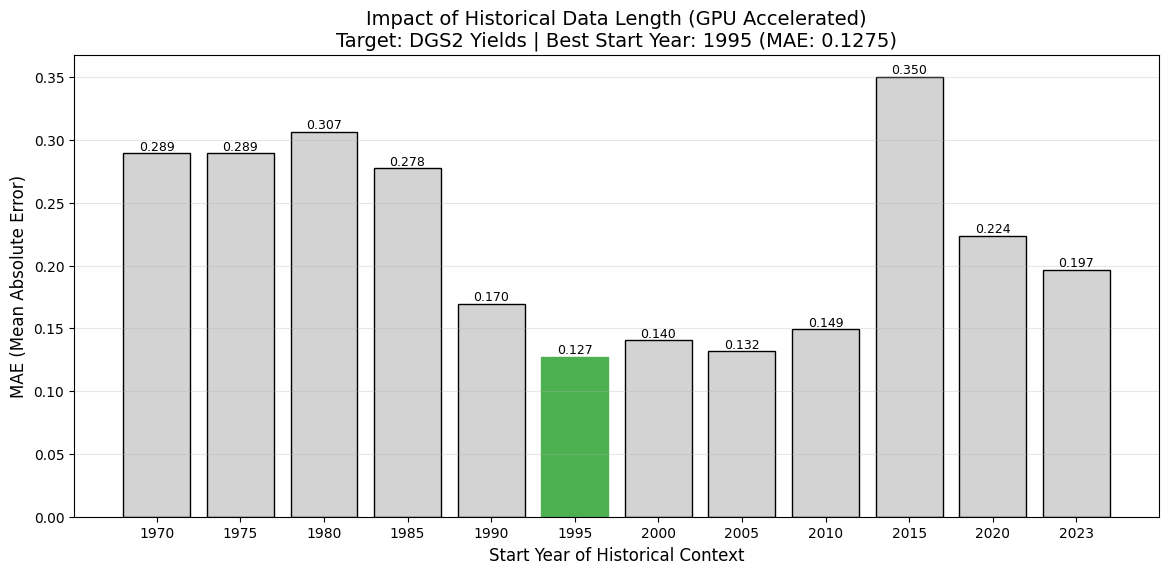


🏆 實驗完成！GPU 運算超快對吧？最佳起始年份: 1995


In [1]:
import pandas as pd
import numpy as np
import torch
import os
import timesfm
import matplotlib.pyplot as plt
from pandas_datareader import data as pdr
from tqdm import tqdm

# --- 1. 設定實驗參數 ---
FRED_API_KEY = os.environ.get('FRED_API_KEY') 
TICKER = 'DGS2' 
FULL_DATA_START = '1970-01-01' 
EXPERIMENT_END_DATE = '2025-11-15' 
TARGET_START = '2025-04-01'
TARGET_END = '2025-10-31'

# 產生測試年份列表
START_YEARS = list(range(1970, 2024, 5)) 
if 2023 not in START_YEARS:
    START_YEARS.append(2023)
START_YEARS.sort()

# --- 2. 準備數據 ---
print(f"--- 下載完整數據 ({FULL_DATA_START} - {EXPERIMENT_END_DATE}) ---")
try:
    # 下載 FRED 數據
    full_df = pdr.get_data_fred(TICKER, start=FULL_DATA_START, end=EXPERIMENT_END_DATE)
    full_df = full_df.dropna()
    full_series = pd.to_numeric(full_df[TICKER], errors='coerce').squeeze()
    
    # 取得 Ground Truth (實際值)
    ground_truth = full_series.loc[TARGET_START:TARGET_END]
    actual_values = ground_truth.values
    
    # 計算需要預測的天數 (Horizon)
    horizon_len = len(actual_values)
    print(f"數據下載完成。預測目標長度 (Horizon): {horizon_len} 天")
    
except Exception as e:
    print(f"數據下載或處理失敗: {e}")
    print("提示：請檢查 FRED_API_KEY 是否正確設定，或網路是否通暢。")
    exit()

# --- 3. 初始化 TimesFM 2.5 (GPU 模式) ---
print(f"\n--- 初始化 TimesFM 2.5 (GPU: {torch.cuda.get_device_name(0)}) ---")
try:
    # [Step 1] 使用新版 API 載入模型
    tfm = timesfm.TimesFM_2p5_200M_torch.from_pretrained(
        "google/timesfm-2.5-200m-pytorch",
        device="cuda",       # ✅ 強制使用 GPU
        torch_compile=False 
    )

    # [Step 2] 設定 ForecastConfig (修正版)
    # ⚠️ 關鍵修正：移除了 num_layers 和 model_dims，只保留預測相關設定
    # 16384 - 256 = 16128 (預留空間給 Horizon)
    config = timesfm.ForecastConfig(
        max_context=16128,
        max_horizon=256,       # 設定一個足夠大的上限
        normalize_inputs=True,
    )
    
    print("正在編譯模型設定 (Compile)...")
    tfm.compile(config)
    print("模型載入成功！開始極速運算...\n")

except Exception as e:
    print(f"模型初始化失敗: {e}")
    # 為了防止在模型壞掉的情況下繼續跑迴圈，這裡直接終止
    import sys
    sys.exit(1) 

# --- 4. 執行實驗迴圈 ---
results = []

# tqdm 進度條
for start_year in tqdm(START_YEARS, desc="GPU 運算中"):
    start_date_str = f"{start_year}-01-01"
    
    # 切割出「歷史輸入數據」 (截止到 2025-03-31，即預測開始前一天)
    context_slice = full_series.loc[start_date_str : '2025-03-31'] 
    
    if context_slice.empty:
        continue
        
    context_array = context_slice.values.astype(np.float32)
    
    # 截斷過長的數據以符合 16k 限制
    if len(context_array) > 16128:
        context_array = context_array[-16128:]

    try:
        # [Step 3] 執行預測 (新版 API)
        # 必須明確傳入 inputs 和 horizon
        forecast_result = tfm.forecast(inputs=[context_array], horizon=horizon_len)
        
        # 處理回傳格式
        if isinstance(forecast_result, tuple):
            forecast_result = forecast_result[0]
            
        # 取出預測值 (Batch 0)
        predicted = forecast_result[0]
        
        # 如果有分位數，預設取第 0 個 (通常是 mean)
        if predicted.ndim > 1: 
             predicted = predicted[:, 0]

        # 確保長度一致
        predicted = predicted[:horizon_len]

        # 計算誤差
        mae = np.mean(np.abs(predicted - actual_values))
        rmse = np.sqrt(np.mean((predicted - actual_values)**2))
        
        results.append({
            'Start_Year': str(start_year),
            'MAE': mae,
            'RMSE': rmse
        })
        
    except Exception as e:
        print(f"\n年份 {start_year} 運算失敗: {e}")

# --- 5. 畫圖 ---
if results:
    df_results = pd.DataFrame(results)
    
    plt.figure(figsize=(14, 6))
    bars = plt.bar(df_results['Start_Year'], df_results['MAE'], color='lightgray', edgecolor='black')
    
    # 標記冠軍
    best_idx = df_results['MAE'].idxmin()
    bars[best_idx].set_color('#4CAF50') 
    bars[best_idx].set_hatch('//')
    
    best_year = df_results.iloc[best_idx]['Start_Year']
    best_mae = df_results.iloc[best_idx]['MAE']
    
    plt.title(f'Impact of Historical Data Length (GPU Accelerated)\nTarget: {TICKER} Yields | Best Start Year: {best_year} (MAE: {best_mae:.4f})', fontsize=14)
    plt.xlabel('Start Year of Historical Context', fontsize=12)
    plt.ylabel('MAE (Mean Absolute Error)', fontsize=12)
    plt.grid(axis='y', alpha=0.3)
    
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height, f'{height:.3f}', ha='center', va='bottom', fontsize=9)

    plt.show()

    print(f"\n🏆 實驗完成！GPU 運算超快對吧？最佳起始年份: {best_year}")
else:
    print("沒有產生任何結果，請檢查數據下載是否成功。")

正在重現最佳年份 (1995) 的預測結果...


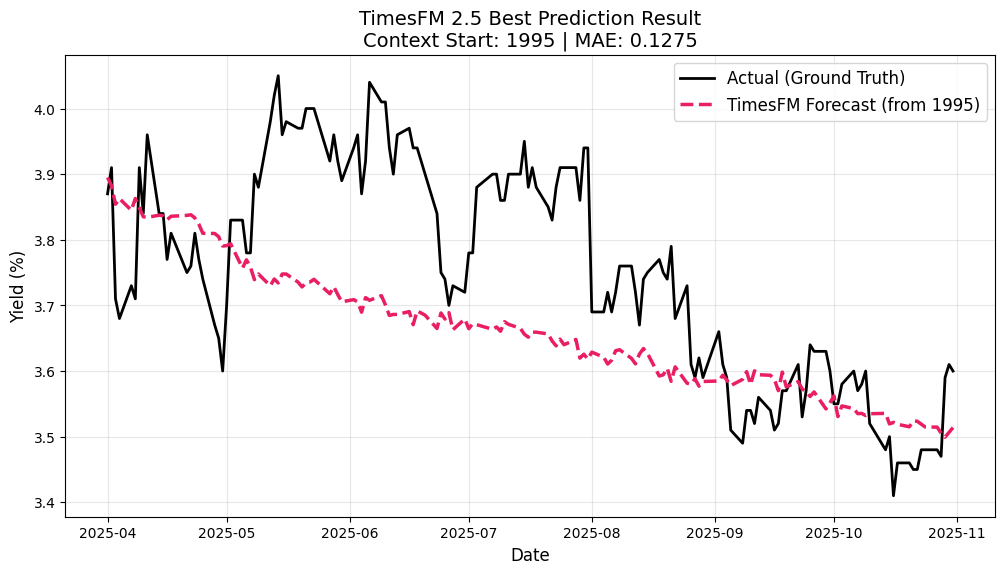

In [3]:
# 確保之前的實驗結果還在
if 'df_results' in locals() and not df_results.empty:
    
    # 1. 找出冠軍年份
    best_row = df_results.loc[df_results['MAE'].idxmin()]
    best_year = best_row['Start_Year']
    best_mae = best_row['MAE']
    
    print(f"正在重現最佳年份 ({best_year}) 的預測結果...")
    
    # 2. 重新準備該年份的輸入數據
    start_date = f"{best_year}-01-01"
    # 輸入數據截止於預測開始前一天 (2025-03-31)
    context_slice = full_series.loc[start_date : '2025-03-31']
    context_array = context_slice.values.astype(np.float32)
    
    # 確保符合長度限制
    if len(context_array) > 16128:
        context_array = context_array[-16128:]
        
    # 3. 再次執行預測 (只跑這一次)
    # horizon_len 應該在之前的步驟已經算好了 (對應 TARGET_START ~ TARGET_END 的長度)
    forecast_result = tfm.forecast(inputs=[context_array], horizon=horizon_len)
    
    if isinstance(forecast_result, tuple):
        forecast_result = forecast_result[0]
    
    # 取出預測值
    prediction = forecast_result[0]
    if prediction.ndim > 1:
        prediction = prediction[:, 0] # 取均值
    prediction = prediction[:horizon_len] # 確保長度對齊
    
    # 4. 畫出漂亮的折線對比圖
    plt.figure(figsize=(12, 6))
    
    # 畫真實數據 (黑線)
    plt.plot(ground_truth.index, actual_values, color='black', linewidth=2, label='Actual (Ground Truth)')
    
    # 畫預測數據 (紅線)
    # 注意：這裡我們用 ground_truth 的日期作為 X 軸，確保時間對齊
    plt.plot(ground_truth.index, prediction, color='#E91E63', linewidth=2.5, linestyle='--', label=f'TimesFM Forecast (from {best_year})')
    
    # 裝飾圖表
    plt.title(f'TimesFM 2.5 Best Prediction Result\nContext Start: {best_year} | MAE: {best_mae:.4f}', fontsize=14)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Yield (%)', fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    
    # 顯示圖表
    plt.show()
    
else:
    print("找不到實驗結果 (df_results)，請先執行上面的迴圈實驗程式碼喔！")

🚀 系統啟動：最終修正版（全部）

[1/5] 下載 target 與建立主索引...

[2/5] 下載並對齊其他指標（每欄位 ffill+bfill）...
✅ 原始合併完成，接下來以欄位為單位補值（ffill/bfill）以保留時間序列長度。

欄位起始檢視（前 20）：
              column first_valid_idx  n_obs
        Target_Yield      1994-01-01  11642
     HY_Spread_Level      1994-01-01  11642
        M2_Money_YoY      1994-01-01  11642
      M2_Money_Level      1994-01-01  11642
      Fed_Assets_YoY      1994-01-01  11642
    Fed_Assets_Level      1994-01-01  11642
           VIX_Level      1994-01-01  11642
         JOLTS_Level      1994-01-01  11642
    Retail_Sales_YoY      1994-01-01  11642
  Retail_Sales_Level      1994-01-01  11642
       ISM_Manuf_YoY      1994-01-01  11642
     ISM_Manuf_Level      1994-01-01  11642
Financial_Cond_Level      1994-01-01  11642
Housing_Starts_Level      1994-01-01  11642
       NonFarm_Level      1994-01-01  11642
  Unemployment_Level      1994-01-01  11642
 Inflation_Exp_Level      1994-01-01  11642
    Import_Price_YoY      1994-01-01  11642
  Import_Price_Level    

✅ 第 1 位入選: Inflation_Exp_Level (MAE: 0.5644)


✅ 第 2 位入選: Fed_Assets_Level (MAE: 0.2924)


✅ 第 3 位入選: Financial_Cond_Level (MAE: 0.2932)


✅ 第 4 位入選: Fed_Assets_YoY (MAE: 0.3142)


...

✅ 第 7 位入選: Import_Price_YoY (MAE: 0.3303)


✅ 第 8 位入選: NonFarm_Level (MAE: 0.3451)


✅ 第 9 位入選: ISM_Manuf_YoY (MAE: 0.3677)


✅ 第 10 位入選: ISM_Manuf_Level (MAE: 0.3361)


✅ 第 11 位入選: M2_Money_Level (MAE: 0.3130)

🏆 最佳純總經組合 (k=11):
['Inflation_Exp_Level', 'Fed_Assets_Level', 'Financial_Cond_Level', 'Fed_Assets_YoY', 'VIX_Level', 'M2_Money_YoY', 'Import_Price_YoY', 'NonFarm_Level', 'ISM_Manuf_YoY', 'ISM_Manuf_Level', 'M2_Money_Level']
🎯 最低 MAE (k=11): 0.3130

執行最終預測與繪圖...


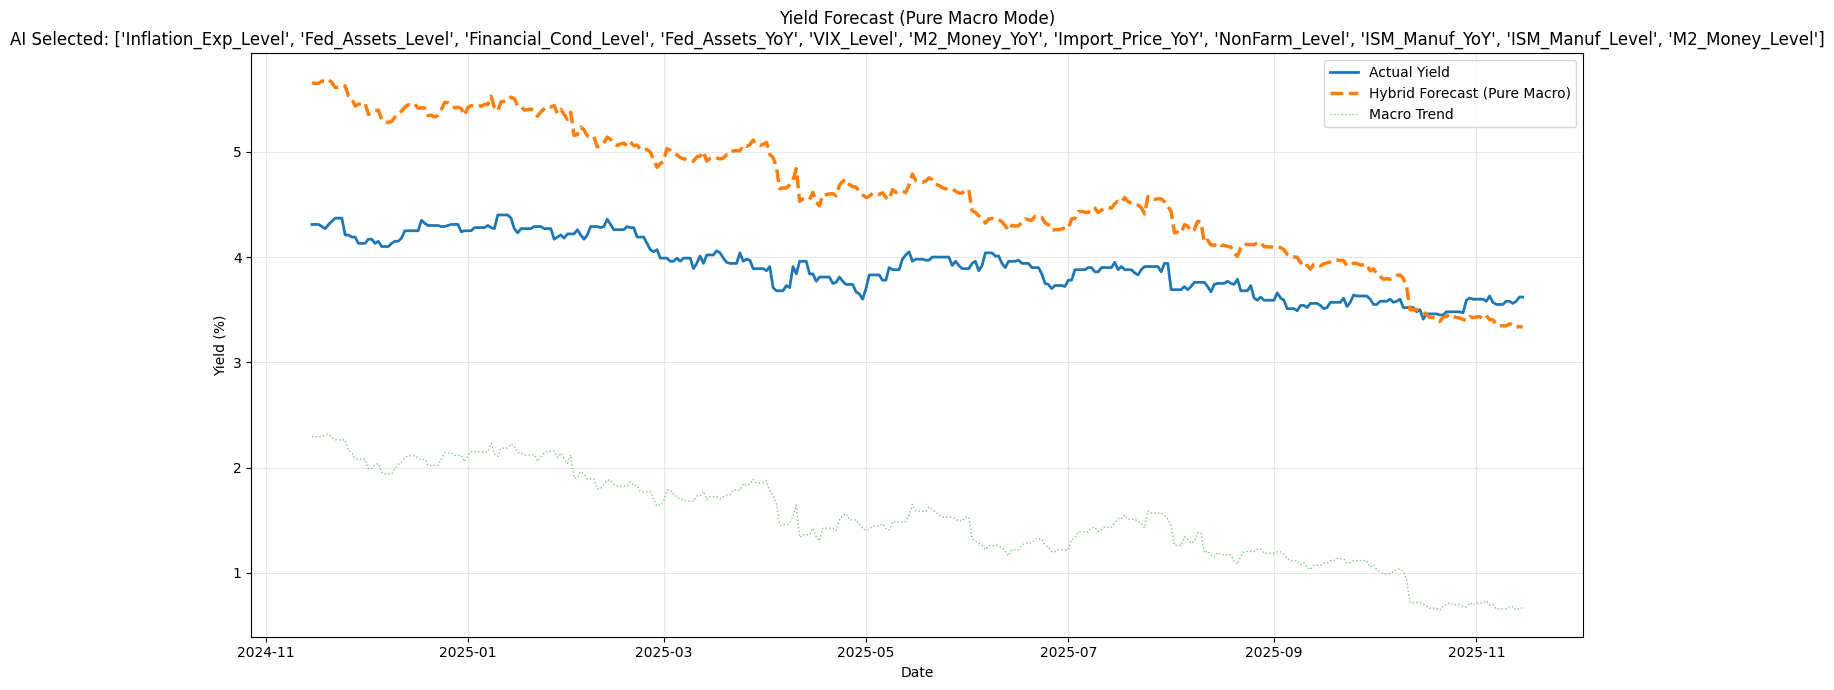

🎉 預測完成！純總經 MAE: 0.7173


In [5]:
# 全部修正版：可直接貼上執行
import pandas as pd
import numpy as np
import os
import yfinance as yf
import torch
import timesfm
import matplotlib.pyplot as plt
from pandas_datareader import data as pdr
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm
import sys
import warnings

warnings.filterwarnings("ignore")
pd.set_option('display.width', 1000)
pd.set_option('display.max_columns', 50)

print("🚀 系統啟動：最終修正版（全部）")

# --- 參數（請視需要調整） ---
FRED_API_KEY = os.environ.get('FRED_API_KEY')
TICKER_TARGET = 'DGS2'
TRAIN_END_DATE = '2022-12-31'         # 你原本使用的訓練終點
TRAIN_END_DATE_ALT = '2024-11-14'     # 如果想用你早先的設定可用這個
TEST_START_DATE = '2024-11-15'        # 必要：在原本程式碼沒定義到
TEST_END_DATE = '2025-11-15'

START_DL = '1994-01-01'
END_DL = TEST_END_DATE

INDICATOR_MAP = {
    'Yield_10Y': {'code': 'DGS10', 'source': 'fred', 'trans': 'level'},
    'Yield_3M': {'code': 'DGS3MO', 'source': 'fred', 'trans': 'level'},
    'Core_CPI': {'code': 'CPILFESL', 'source': 'fred', 'trans': 'dual'},
    'PCE_Price': {'code': 'PCEPI', 'source': 'fred', 'trans': 'dual'},
    'Import_Price': {'code': 'IR', 'source': 'fred', 'trans': 'dual'},
    'Inflation_Exp': {'code': 'T10YIE', 'source': 'fred', 'trans': 'level'},
    'Unemployment': {'code': 'UNRATE', 'source': 'fred', 'trans': 'level'},
    'NonFarm': {'code': 'PAYEMS', 'source': 'fred', 'trans': 'dual'},
    'Housing_Starts': {'code': 'HOUST', 'source': 'fred', 'trans': 'level'},
    'ISM_Manuf': {'code': 'INDPRO', 'source': 'fred', 'trans': 'yoy'},
    'Retail_Sales': {'code': 'RSAFS', 'source': 'fred', 'trans': 'yoy'},
    'JOLTS': {'code': 'JTSJOL', 'source': 'fred', 'trans': 'level'},
    'VIX': {'code': 'VIXCLS', 'source': 'fred', 'trans': 'level'},
    'Fed_Assets': {'code': 'WALCL', 'source': 'fred', 'trans': 'yoy'},
    'M2_Money': {'code': 'M2SL', 'source': 'fred', 'trans': 'yoy'},
    'HY_Spread': {'code': 'BAMLH0A0HYM2', 'source': 'fred', 'trans': 'level'},
    'Financial_Cond': {'code': 'NFCI', 'source': 'fred', 'trans': 'level'},
    'WTI_Oil': {'code': 'CL=F', 'source': 'yfinance', 'trans': 'level'},
}

# --- 下載 target 與建立 master index ---
print("\n[1/5] 下載 target 與建立主索引...")
try:
    target = pdr.get_data_fred(TICKER_TARGET, start=START_DL, end=END_DL)
    target = target.rename(columns={TICKER_TARGET: 'Target_Yield'})
    idx = pd.date_range(start=START_DL, end=END_DL, freq='D')
    master_df = pd.DataFrame(index=idx)
    master_df = master_df.join(target.reindex(idx))
except Exception as e:
    print("❌ 無法從 FRED 下載 Target，錯誤：", e)
    sys.exit(1)

# --- 下載其它指標並對齊（並用欄位 ffill/bfill） ---
print("\n[2/5] 下載並對齊其他指標（每欄位 ffill+bfill）...")
for name, info in INDICATOR_MAP.items():
    try:
        df_temp = None
        if info['source'] == 'fred':
            df_temp = pdr.get_data_fred(info['code'], start=START_DL, end=END_DL)
        elif info['source'] == 'yfinance':
            ticker = yf.Ticker(info['code'])
            hist = ticker.history(start=START_DL, end=END_DL)
            if not hist.empty:
                df_temp = hist[['Close']].rename(columns={'Close': info['code']})
        if df_temp is None:
            print(f"⚠ {name} 無資料，跳過")
            continue

        # 取第一欄並對齊 index
        s_raw = df_temp.iloc[:, 0].reindex(master_df.index)
        master_df[f"{name}_Level"] = s_raw

        if info['trans'] in ['yoy', 'dual']:
            # 簡化：用 252 交易日近似 1 年，若你要真月度請改 periods
            periods = 252
            s_yoy = s_raw.pct_change(periods=periods) * 100
            master_df[f"{name}_YoY"] = s_yoy

    except Exception as e:
        print(f"❌ 下載/處理 {name} 失敗：{e}")

# 額外指標：Spread 10Y-2Y（若有 Level 欄）
if 'Yield_10Y_Level' in master_df.columns and 'Target_Yield' in master_df.columns:
    master_df['Spread_10Y2Y'] = master_df['Yield_10Y_Level'] - master_df['Target_Yield']

print("✅ 原始合併完成，接下來以欄位為單位補值（ffill/bfill）以保留時間序列長度。")

# --- 以欄位單獨補值（避免整表 dropna） ---
for col in master_df.columns:
    master_df[col] = master_df[col].ffill().bfill()

# 檢查每個欄位的第一個有效觀測與非 NaN 計數（輔助 debug）
def inspect_columns(df):
    rows = []
    for c in df.columns:
        nonnull = df[c].first_valid_index()
        count = df[c].count()
        rows.append((c, nonnull, count))
    return pd.DataFrame(rows, columns=['column', 'first_valid_idx', 'n_obs']).sort_values('first_valid_idx')

col_summary = inspect_columns(master_df)
print("\n欄位起始檢視（前 20）：")
print(col_summary.head(20).to_string(index=False))

# --- 產生 clean_df 並 lag 特徵 (Lag 1 day) ---
print("\n[3/5] 生成 Lag-1 特徵並構建 clean_df")
y = master_df[['Target_Yield']].copy()
X = master_df.drop(columns=['Target_Yield']).shift(1)  # 所有特徵 Lag 1 天
clean_df = pd.concat([y, X], axis=1).loc['1995-01-01':TEST_END_DATE]

# 若還有缺值（理論上經過 ffill/bfill 應無），再補一次
clean_df = clean_df.ffill().bfill()

# 最終候選（過濾掉某些名稱）
all_cols = clean_df.columns.drop('Target_Yield')
final_macro_candidates = [c for c in all_cols if ('Yield' not in c and 'Spread' not in c and '3M' not in c and 'Copper' not in c)]
print(f"✅ 數據庫構建完成！最終特徵池大小: {len(final_macro_candidates)} 個")

# --- 初始化 TimesFM（有 GPU 則用 cuda） ---
print("\n[4/5] 初始化 TimesFM（若無 GPU 則提醒）...")
device = "cuda" if torch.cuda.is_available() else "cpu"
if device == "cpu":
    print("⚠ 找不到 CUDA，TimesFM 將在 CPU 上運行（會慢）")
try:
    tfm = timesfm.TimesFM_2p5_200M_torch.from_pretrained(
        "google/timesfm-2.5-200m-pytorch", device=device, torch_compile=False
    )
    tfm.compile(timesfm.ForecastConfig(max_context=2048, max_horizon=300, normalize_inputs=True))
except Exception as e:
    print("❌ 無法初始化 TimesFM（請確認模型檔或網路）：", e)
    tfm = None  # 後面若 None 我們會以基準策略處理

# --- evaluate_robust (加強版：防呆 + 返回大值代替崩潰) ---
def evaluate_robust(features, train_end=TRAIN_END_DATE, test_year='2023'):
    df = clean_df.copy()
    train = df.loc[:train_end]
    test = df.loc[f'{test_year}-01-01':f'{test_year}-12-31']

    # 防呆：train/test 若為空則回傳大 MAE
    if len(train) == 0 or len(test) == 0:
        return 9999

    # 若 features 提供但其中某欄在 train 完全為 NaN，回傳大值
    if features:
        if train[features].dropna().shape[0] == 0:
            return 9999

    # 線性部分
    if features:
        try:
            scaler = StandardScaler()
            X_tr = scaler.fit_transform(train[features].astype(np.float32))
            X_te = scaler.transform(test[features].astype(np.float32))
            lr = LinearRegression().fit(X_tr, train['Target_Yield'].values)
            lin_pred = lr.predict(X_te)
            res_train = train['Target_Yield'].values - lr.predict(X_tr)
        except Exception as e:
            # 若任何錯誤，回傳大值
            return 9999
    else:
        lin_pred = np.zeros(len(test))
        res_train = train['Target_Yield'].values

    # 時序模型部分（TimesFM）
    try:
        if tfm is None:
            # 若 tfm 無法初始化，直接用 residual 平均作為短期"proxy"
            proxy = np.repeat(np.mean(res_train[-256:]) if len(res_train)>0 else 0.0, len(test))
            final_pred = lin_pred + proxy
            return float(np.mean(np.abs(final_pred - test['Target_Yield'].values)))
        else:
            # 送入 TimesFM：保證輸入為 float32 且長度至少 1
            arr = res_train[-2048:].astype(np.float32)
            if arr.shape[0] == 0:
                return 9999
            fcst = tfm.forecast(inputs=[arr], horizon=len(test))
            if isinstance(fcst, tuple):
                fcst = fcst[0]
            res_pred = fcst[0, :len(test)]
            if res_pred.ndim > 1:
                res_pred = res_pred[:, 0]
            final_pred = lin_pred + res_pred
            return float(np.mean(np.abs(final_pred - test['Target_Yield'].values)))
    except Exception as e:
        # 若任何時序模型發生錯誤，回 9999（不 crash）
        return 9999

# --- 特徵選拔（貪婪 forward selection） ---
print("\n[5/5] AI 裁判：執行 5-11 個特徵選拔（貪婪）")
min_k = 5
max_k = 11
selected = []
history_mae = []
best_features_set = []
global_best_mae = float('inf')

base_mae = evaluate_robust([], train_end=TRAIN_END_DATE, test_year='2023')
print(f"基準線 MAE (TimesFM Only proxy): {base_mae:.4f}")

# 加一個快取避免重複計算
cache = {}

for k in range(1, max_k + 1):
    best_feat = None
    best_score = float('inf')
    candidates = [c for c in final_macro_candidates if c not in selected]
    if not candidates:
        break

    for feat in tqdm(candidates, desc=f"Round {k}: testing {len(candidates)}", leave=False):
        key = tuple(selected + [feat])
        if key in cache:
            score = cache[key]
        else:
            score = evaluate_robust(selected + [feat], train_end=TRAIN_END_DATE, test_year='2023')
            cache[key] = score

        if score < best_score:
            best_score = score
            best_feat = feat

    if best_feat is None:
        break

    selected.append(best_feat)
    history_mae.append(best_score)
    print(f"✅ 第 {k} 位入選: {best_feat} (MAE: {best_score:.4f})")

    if k >= min_k:
        if best_score < global_best_mae:
            global_best_mae = best_score
            best_features_set = selected.copy()

    if k == max_k:
        break

if not best_features_set:
    # 若沒在 5-11 找到改善則 fallback：選最前面的 5 個候選
    best_features_set = selected[:min_k]

print("\n" + "="*40)
print(f"🏆 最佳純總經組合 (k={len(best_features_set)}):")
print(best_features_set)
print(f"🎯 最低 MAE (k={len(best_features_set)}): {global_best_mae:.4f}")
print("="*40)

# --- 最終預測（使用 best_features_set） ---
print("\n執行最終預測與繪圖...")
train_df = clean_df.loc[:TRAIN_END_DATE].copy()
test_df = clean_df.loc[TEST_START_DATE:TEST_END_DATE].copy()

# 必要防呆：只保留那些在 train/test 中皆有非空值的特徵
usable_features = [f for f in best_features_set if (train_df[f].notna().sum() > 0 and test_df[f].notna().sum() > 0)]
if len(usable_features) < len(best_features_set):
    print(f"⚠ 以下特徵在 train/test 中有缺失，已移除：{set(best_features_set) - set(usable_features)}")

# 以 selected usable features 為準
final_feats = usable_features
if len(final_feats) == 0:
    raise ValueError("❌ 最終沒有可用特徵，請檢查資料與時間段。")

# Drop rows with NaN in either features or target in train
train_df = train_df.dropna(subset=final_feats + ['Target_Yield'])
test_df = test_df.dropna(subset=final_feats + ['Target_Yield'])

if len(train_df) == 0 or len(test_df) == 0:
    raise ValueError("❌ train_df 或 test_df 經 dropna 後為空，請檢查起訖日期與欄位。")

scaler = StandardScaler()
X_tr = scaler.fit_transform(train_df[final_feats].astype(np.float32))
X_te = scaler.transform(test_df[final_feats].astype(np.float32))
lr = LinearRegression().fit(X_tr, train_df['Target_Yield'].values)

linear_trend = lr.predict(X_te)
residuals_train = train_df['Target_Yield'].values - lr.predict(X_tr)

# TimesFM 預測（若無則使用 residual 平均 proxy）
if tfm is None:
    proxy = np.repeat(np.mean(residuals_train[-256:]), len(test_df))
    residual_trend = proxy
else:
    try:
        arr = residuals_train[-2048:].astype(np.float32)
        fcst = tfm.forecast(inputs=[arr], horizon=len(test_df))
        if isinstance(fcst, tuple):
            fcst = fcst[0]
        residual_trend = fcst[0, :len(test_df)]
        if residual_trend.ndim > 1:
            residual_trend = residual_trend[:, 0]
    except Exception as e:
        print("⚠ TimesFM 在最終預測階段失敗，使用 residual 平均 proxy：", e)
        residual_trend = np.repeat(np.mean(residuals_train[-256:]), len(test_df))

final_pred = linear_trend + residual_trend
actual = test_df['Target_Yield'].values

# 繪圖
plt.figure(figsize=(14, 7))
plt.plot(test_df.index, actual, linewidth=2, label='Actual Yield')
plt.plot(test_df.index, final_pred, linewidth=2.5, linestyle='--', label='Hybrid Forecast (Pure Macro)')
plt.plot(test_df.index, linear_trend, linewidth=1, alpha=0.6, linestyle=':', label='Macro Trend')
plt.title(f'Yield Forecast (Pure Macro Mode)\nAI Selected: {final_feats}', fontsize=12)
plt.xlabel('Date')
plt.ylabel('Yield (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

mae = float(np.mean(np.abs(final_pred - actual)))
print(f"🎉 預測完成！純總經 MAE: {mae:.4f}")


In [6]:
import pandas as pd

# 假設 clean_df 已經在記憶體中 (由上一次運行產生)
# 我們必須檢查 clean_df 之前的 master_df 狀態

print("\n--- 🕵️‍♂️ 數據庫特徵損失診斷 ---")

# 1. 隔離訓練與測試數據 (這個步驟通常不會刪除欄位)
df_pre_dropna = master_df.loc['1995-01-01':TEST_END_DATE]

# 2. 找出哪些欄位在 final dropna 時被移除了 (它們可能包含了太多 NaN)
# 這裡需要重建一下最終的 clean_df 邏輯
# 原始的 clean_df 已經被最後的 dropna(axis=0) 所影響，我們要檢查的是 dropna(axis=1)

# 找出所有包含 NaN 的欄位 (這些就是被犧牲的潛在目標)
nan_cols = df_pre_dropna.columns[df_pre_dropna.isnull().any()].tolist()

print(f"總共觀察到 {len(df_pre_dropna.columns)} 個欄位。")

if len(nan_cols) > 0:
    print("\n⚠️ 偵測到以下欄位在 1995 年代初期有嚴重缺失，最終會被丟棄：")
    print("-" * 50)
    for col in nan_cols:
        # 顯示該欄位有多少 NaN
        na_count = df_pre_dropna[col].isna().sum()
        print(f"❌ {col:<25} 缺失值數量: {na_count} / {len(df_pre_dropna)}")
    print("-" * 50)
    print("結論：您的 AI 只能從剩下約 23 個完整的欄位中選擇。")
else:
    print("數據完整，可能是最終的 Lagging 導致某些特徵被擠出了。")

print(f"✅ 最終候選特徵數 (Final Candidate Pool): {len(final_macro_candidates)} 個")


--- 🕵️‍♂️ 數據庫特徵損失診斷 ---
總共觀察到 28 個欄位。

⚠️ 偵測到以下欄位在 1995 年代初期有嚴重缺失，最終會被丟棄：
--------------------------------------------------
❌ WTI_Oil_Level             缺失值數量: 11277 / 11277
--------------------------------------------------
結論：您的 AI 只能從剩下約 23 個完整的欄位中選擇。
✅ 最終候選特徵數 (Final Candidate Pool): 23 個


C:\Users\user\anaconda3\envs\timesfm\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


正在讀取主目標: DGS2 ...
正在讀取外生變數: FOMC_Sentiment (csv)...
正在讀取外生變數: Yield_Spread (fred)...

✅ 資料整合完成！
總筆數: 3798
包含變數: ['Target', 'FOMC_Sentiment', 'Yield_Spread']
            Target  FOMC_Sentiment  Yield_Spread
DATE                                            
2025-11-10    3.58            -0.1          0.55
2025-11-11    3.58            -0.1          0.55
2025-11-12    3.56            -0.1          0.52
2025-11-13    3.58            -0.1          0.53
2025-11-14    3.62            -0.1          0.52

--- 初始化 TimesFM (GPU: NVIDIA GeForce RTX 5060 Ti) ---
Downloaded.
Compiling model...

開始滾動預測... (Target: Target)


Rolling Forecast: 100%|██████████| 102/102 [00:31<00:00,  3.22it/s]



--- 回測分析報告 ---
平均 MAE: 0.2005


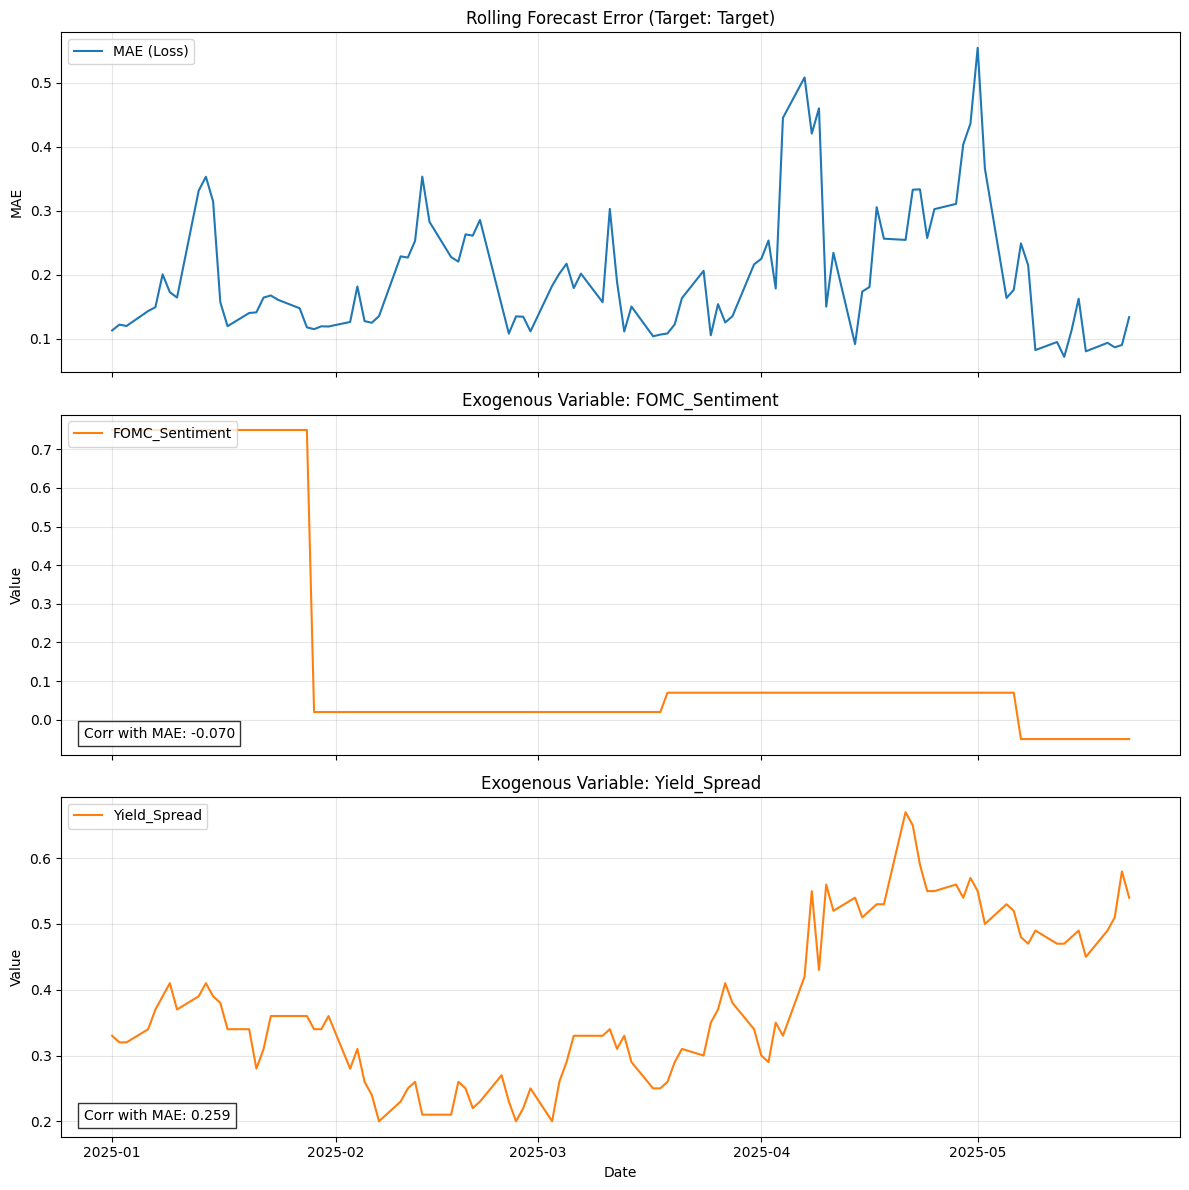

圖表已生成：請檢視誤差與外生變數的連動關係。


In [1]:
import pandas as pd
import numpy as np
import torch
import timesfm
import matplotlib.pyplot as plt
from pandas_datareader import data as pdr
from tqdm import tqdm
from datetime import timedelta
import os

# ==========================================
# --- 1. 高彈性配置區 (Flexibility Configuration) ---
# ==========================================

# 核心目標變數 (我們要預測的)
TARGET_CONFIG = {
    'source': 'fred',
    'ticker': 'DGS2',   # 2年期美債
    'name': 'Target'    # 在 DataFrame 中的欄位名稱
}

# 外生變數配置清單 (想加新變數，就在這裡加一行)
# 支援類型: 'csv', 'fred'
EXOG_SOURCES = [
    # 1. 你的 CSV 外生變數 (例如 FOMC 分數)
    {
        'source': 'csv',
        'path': 'FOMC_daily_score_only2.csv',
        'col_to_use': 'Score',      # CSV 裡原本的欄位名稱
        'name': 'FOMC_Sentiment'    # 載入後你想叫它什麼名字
    },
    # 2. FRED 外生變數 (例如 10年-2年 利差)
    {
        'source': 'fred',
        'ticker': 'T10Y2Y',
        'name': 'Yield_Spread'
    },
    # 3. (範例) 未來想加油價 CSV，只要解開註解即可
    # {
    #     'source': 'csv',
    #     'path': 'oil_price.csv',
    #     'col_to_use': 'Close',
    #     'name': 'Oil_Price'
    # },
]

# 實驗時間參數
DATA_START_DATE = '2010-01-01'
DATA_END_DATE = '2025-11-15'
TEST_START_DATE = '2025-01-01'
FORECAST_HORIZON_MONTHS = 6
HORIZON_LEN = 21 * FORECAST_HORIZON_MONTHS  # ~126 days

# ==========================================
# --- 2. 彈性資料載入器 (Flexible Data Loader) ---
# ==========================================

class FlexibleDataLoader:
    def __init__(self, start_date, end_date):
        self.start_date = start_date
        self.end_date = end_date
        self.data_store = {} # 暫存讀進來的資料

    def load_all(self, target_conf, exog_confs):
        # 1. 先讀取 Target (作為主索引 Index 的基準)
        print(f"正在讀取主目標: {target_conf['ticker']} ...")
        main_df = self._fetch_data(target_conf)
        
        # 2. 迴圈讀取所有外生變數
        for conf in exog_confs:
            print(f"正在讀取外生變數: {conf.get('name', 'Unknown')} ({conf['source']})...")
            try:
                exog_df = self._fetch_data(conf)
                # Left Join: 以 Target 的交易日為主，將外生變數併進來
                # 這會自動過濾掉 CSV 中的非交易日 (如週末)
                main_df = main_df.join(exog_df, how='left')
            except Exception as e:
                print(f"⚠️ 警告: 變數 {conf.get('name')} 讀取失敗，將跳過。錯誤: {e}")

        # 3. 全局補值 (Forward Fill)
        # 金融數據常用技巧：若當天沒數據 (例如假日的 CSV 空缺)，延續前一天的值
        main_df = main_df.ffill().dropna()
        return main_df

    def _fetch_data(self, conf):
        """根據配置類型，分流處理"""
        if conf['source'] == 'fred':
            df = pdr.get_data_fred(conf['ticker'], start=self.start_date, end=self.end_date)
            df.columns = [conf['name']] # 重新命名
            return df
            
        elif conf['source'] == 'csv':
            if not os.path.exists(conf['path']):
                raise FileNotFoundError(f"找不到檔案: {conf['path']}")
            
            df = pd.read_csv(conf['path'])
            # 智慧判斷日期欄位 (假設含有 'date' 字串的欄位是日期)
            date_col = next((col for col in df.columns if 'date' in col.lower()), None)
            if not date_col:
                raise ValueError("CSV 中找不到日期欄位 (需包含 'Date' 字眼)")
            
            df[date_col] = pd.to_datetime(df[date_col])
            df.set_index(date_col, inplace=True)
            
            # 只取需要的欄位並改名
            target_col = conf.get('col_to_use', df.columns[0]) # 沒指定就拿第一欄
            df = df[[target_col]].rename(columns={target_col: conf['name']})
            return df
            
        else:
            raise ValueError(f"不支援的資料來源類型: {conf['source']}")

# --- 執行資料整合 ---
loader = FlexibleDataLoader(DATA_START_DATE, DATA_END_DATE)
df_merged = loader.load_all(TARGET_CONFIG, EXOG_SOURCES)

print(f"\n✅ 資料整合完成！")
print(f"總筆數: {len(df_merged)}")
print(f"包含變數: {df_merged.columns.tolist()}")
print(df_merged.tail())

# ==========================================
# --- 3. 模型預測與回測 (Rolling Forecast) ---
# ==========================================

print(f"\n--- 初始化 TimesFM (GPU: {torch.cuda.get_device_name(0)}) ---")
tfm = timesfm.TimesFM_2p5_200M_torch.from_pretrained(
    "google/timesfm-2.5-200m-pytorch",
    device="cuda",
    torch_compile=True
)

# 這裡即使 Horizon 很大也沒關係，重點是 Context 長度
config = timesfm.ForecastConfig(
    max_context=4096, 
    max_horizon=HORIZON_LEN + 30,
    normalize_inputs=True,
)
tfm.compile(config)

# 準備回測
results = []
target_col_name = TARGET_CONFIG['name']
test_dates = pd.date_range(start=TEST_START_DATE, end=df_merged.index[-HORIZON_LEN-1], freq='B')
valid_test_dates = [d for d in test_dates if d in df_merged.index]

print(f"\n開始滾動預測... (Target: {target_col_name})")

for current_date in tqdm(valid_test_dates, desc="Rolling Forecast"):
    # 1. 準備 Context (歷史數據)
    # 目前 TimesFM 是單變量模型，我們取 Target 的歷史值
    # (註：若未來使用多變量模型，這裡可以直接取 df_merged 的多欄位)
    past_data = df_merged.loc[:current_date - timedelta(days=1)]
    context_values = past_data[target_col_name].values.astype(np.float32)
    
    # 2. 準備 Ground Truth (未來真實值)
    future_truth = df_merged.loc[current_date:].head(HORIZON_LEN)[target_col_name].values
    
    if len(future_truth) < HORIZON_LEN:
        break
        
    try:
        # 3. 執行預測
        forecast_out = tfm.forecast(inputs=[context_values], horizon=HORIZON_LEN)
        
        # 4. 提取結果
        if isinstance(forecast_out, tuple): forecast_out = forecast_out[0]
        pred = forecast_out[0]
        if pred.ndim > 1: pred = pred[:, 0]
        pred = pred[:len(future_truth)]
        
        # 5. 計算誤差
        mae = np.mean(np.abs(pred - future_truth))
        rmse = np.sqrt(np.mean((pred - future_truth)**2))
        
        # 6. 紀錄 (包含當時的外生變數狀態，方便後續分析)
        record = {
            'Date': current_date,
            'MAE': mae,
            'RMSE': rmse,
        }
        # 自動把所有外生變數當天數值也記下來
        for col in df_merged.columns:
            if col != target_col_name:
                record[col] = df_merged.loc[current_date, col]
                
        results.append(record)

    except Exception as e:
        print(f"Error on {current_date}: {e}")

# ==========================================
# --- 4. 結果分析與繪圖 ---
# ==========================================
if results:
    res_df = pd.DataFrame(results)
    res_df.set_index('Date', inplace=True)
    
    print("\n--- 回測分析報告 ---")
    print(f"平均 MAE: {res_df['MAE'].mean():.4f}")
    
    # 動態繪圖：根據有多少外生變數來決定畫多少子圖
    # 找出所有外生變數欄位
    exog_cols = [c for c in res_df.columns if c not in ['MAE', 'RMSE']]
    n_plots = 1 + len(exog_cols)
    
    fig, axes = plt.subplots(n_plots, 1, figsize=(12, 4 * n_plots), sharex=True)
    if n_plots == 1: axes = [axes] # 處理單一子圖情況
    
    # Plot 1: 預測誤差
    axes[0].plot(res_df.index, res_df['MAE'], color='#1f77b4', label='MAE (Loss)')
    axes[0].set_title(f'Rolling Forecast Error (Target: {target_col_name})')
    axes[0].set_ylabel('MAE')
    axes[0].grid(True, alpha=0.3)
    axes[0].legend(loc='upper left')
    
    # Plot 2+: 外生變數對照
    for i, col in enumerate(exog_cols):
        ax = axes[i+1]
        ax.plot(res_df.index, res_df[col], color='#ff7f0e', label=col)
        ax.set_title(f'Exogenous Variable: {col}')
        ax.set_ylabel('Value')
        ax.grid(True, alpha=0.3)
        ax.legend(loc='upper left')
        
        # 算一下相關係數
        corr = res_df['MAE'].corr(res_df[col])
        ax.text(0.02, 0.05, f'Corr with MAE: {corr:.3f}', transform=ax.transAxes, 
                bbox=dict(facecolor='white', alpha=0.8))

    plt.xlabel('Date')
    plt.tight_layout()
    plt.show()
    
    print("圖表已生成：請檢視誤差與外生變數的連動關係。")
else:
    print("未產生結果。")

正在讀取主目標: DGS2 ...

--- 初始化 TimesFM (GPU: NVIDIA GeForce RTX 5060 Ti) ---
Downloaded.
Compiling model...

開始滾動預測 (共 102 次)...


Rolling Forecast: 100%|██████████| 102/102 [00:31<00:00,  3.24it/s]


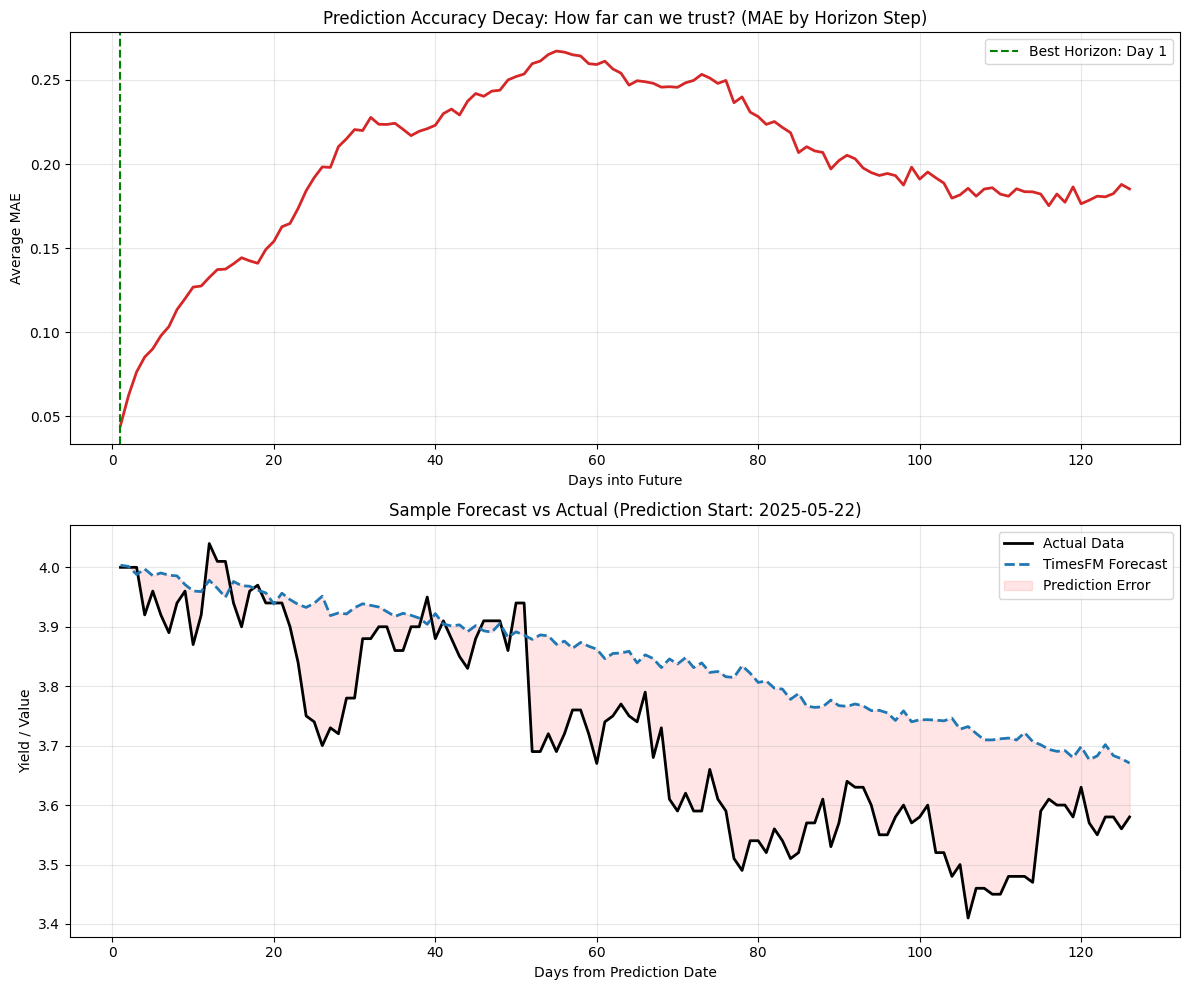


分析結果：
1. 平均預測誤差最低點出現在第 1 天 (MAE: 0.0446)。
2. 請觀察上方紅色曲線 (圖1)，若曲線快速上升，代表模型對長天期預測能力下降快。
3. 下方圖表 (圖2) 展示了最後一次預測的實際走勢對比，紅色陰影面積越小代表越準。


In [2]:
import pandas as pd
import numpy as np
import torch
import timesfm
import matplotlib.pyplot as plt
from pandas_datareader import data as pdr
from tqdm import tqdm
from datetime import timedelta
import os

# ==========================================
# 1. 數據載入與防偷看配置
# ==========================================

# 設定目標與外生變數
TARGET_CONFIG = {'source': 'fred', 'ticker': 'DGS2', 'name': 'Target'}
EXOG_SOURCES = [
    {'source': 'csv', 'path': 'FOMC_daily_score_only2.csv', 'col_to_use': 'Score', 'name': 'FOMC_Sentiment'},
    {'source': 'fred', 'ticker': 'T10Y2Y', 'name': 'Yield_Spread'},
]

# 時間參數
DATA_START_DATE = '2010-01-01'
DATA_END_DATE = '2025-11-15'
TEST_START_DATE = '2025-01-01'
FORECAST_HORIZON_MONTHS = 6
HORIZON_LEN = 21 * FORECAST_HORIZON_MONTHS  # 約 126 天

# 資料載入類別 (保持之前的彈性設計)
class FlexibleDataLoader:
    def __init__(self, start_date, end_date):
        self.start_date = start_date
        self.end_date = end_date

    def load_all(self, target_conf, exog_confs):
        print(f"正在讀取主目標: {target_conf['ticker']} ...")
        main_df = self._fetch_data(target_conf)
        
        for conf in exog_confs:
            try:
                exog_df = self._fetch_data(conf)
                # Left Join 確保只保留交易日，並避免引入未來日期的索引
                main_df = main_df.join(exog_df, how='left')
            except Exception as e:
                print(f"變數 {conf.get('name')} 讀取失敗: {e}")

        # 使用 Forward Fill 補值，模擬「直到有新數據前，市場假設數據不變」
        # 這也是防止偷看未來的合理補值方式
        main_df = main_df.ffill().dropna()
        return main_df

    def _fetch_data(self, conf):
        if conf['source'] == 'fred':
            df = pdr.get_data_fred(conf['ticker'], start=self.start_date, end=self.end_date)
            df.columns = [conf['name']]
            return df
        elif conf['source'] == 'csv':
            if not os.path.exists(conf['path']): raise FileNotFoundError(f"Missing: {conf['path']}")
            df = pd.read_csv(conf['path'])
            date_col = next((c for c in df.columns if 'date' in c.lower()), None)
            df[date_col] = pd.to_datetime(df[date_col])
            df.set_index(date_col, inplace=True)
            target = conf.get('col_to_use', df.columns[0])
            return df[[target]].rename(columns={target: conf['name']})
        return pd.DataFrame()

# 執行載入
loader = FlexibleDataLoader(DATA_START_DATE, DATA_END_DATE)
df_merged = loader.load_all(TARGET_CONFIG, EXOG_SOURCES)

# ==========================================
# 2. 模型初始化與嚴格回測
# ==========================================

print(f"\n--- 初始化 TimesFM (GPU: {torch.cuda.get_device_name(0)}) ---")
tfm = timesfm.TimesFM_2p5_200M_torch.from_pretrained(
    "google/timesfm-2.5-200m-pytorch", device="cuda", torch_compile=True
)
config = timesfm.ForecastConfig(max_context=4096, max_horizon=HORIZON_LEN + 30, normalize_inputs=True)
tfm.compile(config)

# 準備儲存「期限結構誤差」 (每一天預測未來的誤差分布)
error_by_step_list = [] 
results = []
target_col = TARGET_CONFIG['name']

# 為了最後畫圖，我們暫存「最後一次」的預測資料
last_prediction_data = {}

test_dates = [d for d in pd.date_range(TEST_START_DATE, df_merged.index[-HORIZON_LEN-1], freq='B') if d in df_merged.index]

print(f"\n開始滾動預測 (共 {len(test_dates)} 次)...")

for current_date in tqdm(test_dates, desc="Rolling Forecast"):
    
    # [關鍵防偷看邏輯]
    # loc[:current_date - 1 day] 確保絕對不包含今天的收盤價
    past_data = df_merged.loc[:current_date - timedelta(days=1)]
    context_values = past_data[target_col].values.astype(np.float32)
    
    # Ground Truth: 從今天開始往後的真實數據
    future_truth = df_merged.loc[current_date:].head(HORIZON_LEN)[target_col].values
    
    if len(future_truth) < HORIZON_LEN: break
        
    try:
        # 預測
        forecast_out = tfm.forecast(inputs=[context_values], horizon=HORIZON_LEN)
        if isinstance(forecast_out, tuple): forecast_out = forecast_out[0]
        pred = forecast_out[0]
        if pred.ndim > 1: pred = pred[:, 0]
        pred = pred[:len(future_truth)]
        
        # 1. 計算整體平均誤差 (Scalar)
        mae = np.mean(np.abs(pred - future_truth))
        rmse = np.sqrt(np.mean((pred - future_truth)**2))
        results.append({'Date': current_date, 'MAE': mae, 'RMSE': rmse})
        
        # 2. [新增] 計算逐日誤差 (Vector)，用於分析「預測多久會準」
        # 這會存下 [第1天誤差, 第2天誤差, ... 第126天誤差]
        step_errors = np.abs(pred - future_truth)
        error_by_step_list.append(step_errors)
        
        # 3. 更新最後一次的預測紀錄 (用於畫圖)
        last_prediction_data = {
            'date': current_date,
            'pred': pred,
            'truth': future_truth,
            'days': np.arange(1, len(pred) + 1)
        }

    except Exception as e:
        print(f"Error: {e}")

# ==========================================
# 3. 視覺化分析：多久比較準 & 實際vs預測
# ==========================================

if results:
    res_df = pd.DataFrame(results).set_index('Date')
    
    # --- 圖表 1: 誤差期限結構分析 (分析多久會比較準) ---
    # 將所有回測的誤差疊加起來取平均
    all_errors_matrix = np.vstack(error_by_step_list) # Shape: (Test_Days, Horizon)
    avg_mae_by_horizon = np.mean(all_errors_matrix, axis=0) # Shape: (Horizon,)
    
    plt.figure(figsize=(12, 10))
    
    # 子圖 1: 預測天數 vs 平均誤差
    plt.subplot(2, 1, 1)
    plt.plot(range(1, len(avg_mae_by_horizon)+1), avg_mae_by_horizon, color='#d62728', linewidth=2)
    plt.title('Prediction Accuracy Decay: How far can we trust? (MAE by Horizon Step)')
    plt.xlabel('Days into Future')
    plt.ylabel('Average MAE')
    plt.grid(True, alpha=0.3)
    
    # 標記誤差最小的天數 (最佳預測區間)
    best_day = np.argmin(avg_mae_by_horizon) + 1
    min_err = np.min(avg_mae_by_horizon)
    plt.axvline(best_day, color='green', linestyle='--', label=f'Best Horizon: Day {best_day}')
    plt.legend()
    
    # 子圖 2: 最後一次回測的「真實 vs 預測」對比
    plt.subplot(2, 1, 2)
    if last_prediction_data:
        days = last_prediction_data['days']
        plt.plot(days, last_prediction_data['truth'], label='Actual Data', color='black', linewidth=2)
        plt.plot(days, last_prediction_data['pred'], label='TimesFM Forecast', color='#1f77b4', linestyle='--', linewidth=2)
        
        # 畫出誤差區域
        plt.fill_between(days, last_prediction_data['truth'], last_prediction_data['pred'], 
                         color='red', alpha=0.1, label='Prediction Error')
        
        start_date_str = last_prediction_data['date'].strftime('%Y-%m-%d')
        plt.title(f'Sample Forecast vs Actual (Prediction Start: {start_date_str})')
        plt.xlabel('Days from Prediction Date')
        plt.ylabel('Yield / Value')
        plt.legend()
        plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    
    print(f"\n分析結果：")
    print(f"1. 平均預測誤差最低點出現在第 {best_day} 天 (MAE: {min_err:.4f})。")
    print(f"2. 請觀察上方紅色曲線 (圖1)，若曲線快速上升，代表模型對長天期預測能力下降快。")
    print(f"3. 下方圖表 (圖2) 展示了最後一次預測的實際走勢對比，紅色陰影面積越小代表越準。")

else:
    print("無結果。")

In [3]:
import pandas as pd
import numpy as np
import torch
import timesfm
import matplotlib.pyplot as plt
from pandas_datareader import data as pdr
from tqdm import tqdm
from datetime import timedelta
import os

# ==========================================
# 1. 高彈性配置區 (只要改這裡就能加變數)
# ==========================================

# 核心目標 (你要預測的東西)
TARGET_CONFIG = {'source': 'fred', 'ticker': 'DGS2', 'name': 'Target'}

# 外生變數清單 (未來想加新的，複製格式貼上即可)
EXOG_CONFIGS = [
    # 你的 CSV 檔案
    {
        'source': 'csv', 
        'path': 'FOMC_daily_score_only2.csv', 
        'col_to_use': 'Score',  # CSV 裡的欄位名
        'name': 'FOMC_Sentiment' # 讀進來後的變數名
    },
    # 範例：加一個 FRED 的利差數據
    {
        'source': 'fred', 
        'ticker': 'T10Y2Y', 
        'name': 'Yield_Spread'
    },
    # 未來如果要加油價，解開下面註解即可
    # {'source': 'csv', 'path': 'oil_prices.csv', 'col_to_use': 'Close', 'name': 'Oil'},
]

# 時間與參數
DATA_START = '2010-01-01'
DATA_END = '2025-11-15'   # 為了有 Ground Truth，數據要抓得比預測日更遠
TEST_START = '2025-01-01' # 開始回測的日期
FORECAST_MONTHS = 6
HORIZON_LEN = 21 * FORECAST_MONTHS # 預測長度 (約 126 天)

# ==========================================
# 2. 智慧型資料載入器 (處理對齊與合併)
# ==========================================

class SmartDataLoader:
    def __init__(self, start, end):
        self.start = start
        self.end = end
    
    def load(self, target_conf, exog_confs):
        print(f"正在讀取主目標: {target_conf['ticker']} ...")
        # 1. 讀取 Target (作為主索引)
        main_df = self._fetch(target_conf)
        
        # 2. 迴圈讀取所有外生變數並合併
        for conf in exog_confs:
            try:
                print(f" -> 載入外生變數: {conf['name']}")
                exog_df = self._fetch(conf)
                # Left Join: 確保只保留 Target 存在的交易日，避免引入非交易日
                main_df = main_df.join(exog_df, how='left')
            except Exception as e:
                print(f"    ⚠️ 警告: 變數 {conf.get('name')} 讀取失敗 ({e})")
        
        # 3. 補值: 使用 Forward Fill (模擬真實世界: 沒新數據就假設跟昨天一樣)
        return main_df.ffill().dropna()

    def _fetch(self, conf):
        if conf['source'] == 'fred':
            df = pdr.get_data_fred(conf['ticker'], start=self.start, end=self.end)
            df.columns = [conf['name']]
            return df
        elif conf['source'] == 'csv':
            if not os.path.exists(conf['path']): raise FileNotFoundError(f"找不到 {conf['path']}")
            df = pd.read_csv(conf['path'])
            # 自動找日期欄位
            date_col = next((c for c in df.columns if 'date' in c.lower()), None)
            df[date_col] = pd.to_datetime(df[date_col])
            df.set_index(date_col, inplace=True)
            col = conf.get('col_to_use', df.columns[0])
            return df[[col]].rename(columns={col: conf['name']})
        return pd.DataFrame()

# 載入資料
loader = SmartDataLoader(DATA_START, DATA_END)
df_merged = loader.load(TARGET_CONFIG, EXOG_CONFIGS)
print(f"資料準備完成，總筆數: {len(df_merged)}")

# ==========================================
# 3. TimesFM 模型回測 (含防偷看機制)
# ==========================================

print(f"\n--- 初始化 TimesFM (GPU: {torch.cuda.get_device_name(0)}) ---")
tfm = timesfm.TimesFM_2p5_200M_torch.from_pretrained(
    "google/timesfm-2.5-200m-pytorch", device="cuda", torch_compile=True
)
config = timesfm.ForecastConfig(max_context=4096, max_horizon=HORIZON_LEN+20, normalize_inputs=True)
tfm.compile(config)

# 儲存結果容器
results = []
errors_by_step = [] # 用來存每一天(Day 1 ~ Day 126)的誤差
last_run_data = {}  # 用來存最後一次的詳細數據畫圖用

test_dates = [d for d in pd.date_range(TEST_START, df_merged.index[-HORIZON_LEN-1], freq='B') if d in df_merged.index]

print(f"開始滾動回測... (共 {len(test_dates)} 個測試點)")

for current_date in tqdm(test_dates, desc="Rolling Forecast"):
    
    # [絕對防偷看切割]
    # 只能看到 current_date "前一天" 的資料
    past_data = df_merged.loc[:current_date - timedelta(days=1)]
    
    # 這裡目前示範 TimesFM 單變量輸入 (取 Target 欄位)
    # 若未來使用多變量模型，可直接改取 df_merged 所有欄位
    context = past_data[TARGET_CONFIG['name']].values.astype(np.float32)
    
    # Ground Truth (未來解答)
    future_truth = df_merged.loc[current_date:].head(HORIZON_LEN)[TARGET_CONFIG['name']].values
    
    if len(future_truth) < HORIZON_LEN: break

    try:
        # 預測
        forecast = tfm.forecast(inputs=[context], horizon=HORIZON_LEN)
        pred = forecast[0] if isinstance(forecast, tuple) else forecast
        if pred.ndim > 1: pred = pred[0][:, 0] # 取 batch 0, quantile 0
        pred = pred[:len(future_truth)]

        # 1. 紀錄整體誤差
        mae = np.mean(np.abs(pred - future_truth))
        results.append({'Date': current_date, 'MAE': mae})
        
        # 2. 紀錄「每一步」的誤差 (為了分析多久會準)
        step_error = np.abs(pred - future_truth)
        errors_by_step.append(step_error)
        
        # 3. 暫存最後一次的資料 (為了畫對比圖)
        last_run_data = {'pred': pred, 'truth': future_truth, 'date': current_date}

    except Exception as e:
        print(f"Error on {current_date}: {e}")

# ==========================================
# 4. 分析與視覺化 (關鍵洞察)
# ==========================================

if results:
    # --- 圖表 1: 預測準確度 vs 天數 (Optimal Horizon) ---
    # 計算平均每一個天期 (Day 1, Day 2...) 的誤差
    avg_error_curve = np.mean(np.vstack(errors_by_step), axis=0)
    
    plt.figure(figsize=(12, 10))
    
    plt.subplot(2, 1, 1)
    plt.plot(range(1, len(avg_error_curve)+1), avg_error_curve, color='#d62728', linewidth=2)
    plt.title('準確度衰退分析: 預測第幾天最準? (Average MAE by Horizon Step)', fontsize=14)
    plt.xlabel('預測未來第 N 天 (Days into Future)')
    plt.ylabel('平均誤差 (MAE)')
    plt.grid(True, alpha=0.3)
    
    # 標記最佳點
    best_day = np.argmin(avg_error_curve) + 1
    plt.axvline(best_day, color='green', linestyle='--', label=f'誤差最低點: 第 {best_day} 天')
    plt.legend()

    # --- 圖表 2: 最後一次預測 vs 實際走勢 (Final Forecast Check) ---
    plt.subplot(2, 1, 2)
    days_axis = range(1, len(last_run_data['pred'])+1)
    plt.plot(days_axis, last_run_data['truth'], label='實際行情 (Actual)', color='black', linewidth=2)
    plt.plot(days_axis, last_run_data['pred'], label='模型預測 (Forecast)', color='#1f77b4', linestyle='--', linewidth=2)
    
    # 畫出誤差陰影
    plt.fill_between(days_axis, last_run_data['truth'], last_run_data['pred'], color='red', alpha=0.1, label='誤差範圍')
    
    date_str = last_run_data['date'].strftime('%Y-%m-%d')
    plt.title(f'最後一次回測結果對比 (預測基準日: {date_str})', fontsize=14)
    plt.xlabel('未來天數')
    plt.ylabel('數值')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"\n【分析報告】")
    print(f"1. 預測準度期限：請看第一張紅線圖。曲線最低點代表模型最擅長的預測區間 (目前在第 {best_day} 天)。")
    print(f"   如果曲線在 30 天後快速上升，建議只採信模型一個月內的預測。")
    print(f"2. 實際差異檢視：請看第二張圖。這是模型在最後一天 ({date_str}) 對未來半年的看法與實際行情的差距。")

else:
    print("沒有產生回測結果。")

正在讀取主目標: DGS2 ...
 -> 載入外生變數: FOMC_Sentiment
 -> 載入外生變數: Yield_Spread
資料準備完成，總筆數: 3798

--- 初始化 TimesFM (GPU: NVIDIA GeForce RTX 5060 Ti) ---
Downloaded.
Compiling model...
開始滾動回測... (共 102 個測試點)


Rolling Forecast:   1%|          | 1/102 [00:00<00:30,  3.32it/s]

Error on 2025-01-01 00:00:00: too many indices for array: array is 1-dimensional, but 2 were indexed


Rolling Forecast:   2%|▏         | 2/102 [00:00<00:30,  3.30it/s]

Error on 2025-01-02 00:00:00: too many indices for array: array is 1-dimensional, but 2 were indexed


...

Error on 2025-05-20 00:00:00: too many indices for array: array is 1-dimensional, but 2 were indexed


Rolling Forecast:  99%|█████████▉| 101/102 [00:31<00:00,  3.33it/s]

Error on 2025-05-21 00:00:00: too many indices for array: array is 1-dimensional, but 2 were indexed


Rolling Forecast: 100%|██████████| 102/102 [00:31<00:00,  3.23it/s]

Error on 2025-05-22 00:00:00: too many indices for array: array is 1-dimensional, but 2 were indexed
沒有產生回測結果。


In [6]:
import pandas as pd
import numpy as np
import torch
import timesfm
import matplotlib.pyplot as plt
from pandas_datareader import data as pdr
from tqdm import tqdm
from datetime import timedelta
import os

# ==========================================
# 1. 實驗參數配置 (Configuration)
# ==========================================

# 核心目標 (你要預測的變數)
TARGET_CONFIG = {
    'source': 'fred', 
    'ticker': 'DGS2',   # 2年期美債殖利率
    'name': 'Target'
}

# 外生變數配置 (這裡放入你的 CSV)
EXOG_CONFIGS = [
    {
        'source': 'csv', 
        'path': 'FOMC_daily_score_only2.csv', 
        'col_to_use': 'Score',      # CSV 裡的欄位名稱
        'name': 'FOMC_Sentiment'    # 載入後的新名稱
    },
    # 你可以隨時在這裡增加新的變數，例如 FRED 的利差
    {
        'source': 'fred', 
        'ticker': 'T10Y2Y', 
        'name': 'Yield_Spread'
    }
]

# 時間設定
DATA_START = '2010-01-01'
DATA_END = '2025-11-15'   # 抓取較長的時間以包含 Ground Truth
TEST_START = '2025-01-01' # 真正開始回測的日期
FORECAST_MONTHS = 6
HORIZON_LEN = 21 * FORECAST_MONTHS # 約 126 天

# ==========================================
# 2. 智慧型資料載入器 (Data Loader)
# ==========================================

class SmartDataLoader:
    def __init__(self, start, end):
        self.start = start
        self.end = end
    
    def load(self, target_conf, exog_confs):
        print(f"正在讀取主目標: {target_conf['ticker']} ...")
        # 1. 讀取 Target (作為主索引，確保是交易日)
        main_df = self._fetch(target_conf)
        
        # 2. 迴圈讀取並合併外生變數
        for conf in exog_confs:
            try:
                print(f" -> 載入外生變數: {conf['name']}")
                exog_df = self._fetch(conf)
                # Left Join: 確保只保留主目標存在的交易日 (過濾掉週末/假日)
                main_df = main_df.join(exog_df, how='left')
            except Exception as e:
                print(f"    ⚠️ 警告: 變數 {conf.get('name')} 讀取失敗 ({e})，將跳過。")
        
        # 3. 補值: 使用 Forward Fill (模擬真實世界：無新消息時沿用舊數據)
        return main_df.ffill().dropna()

    def _fetch(self, conf):
        if conf['source'] == 'fred':
            df = pdr.get_data_fred(conf['ticker'], start=self.start, end=self.end)
            df.columns = [conf['name']]
            return df
            
        elif conf['source'] == 'csv':
            if not os.path.exists(conf['path']):
                print(f"錯誤: 找不到檔案 {conf['path']}")
                return pd.DataFrame()
            
            df = pd.read_csv(conf['path'])
            # 自動搜尋日期欄位
            date_col = next((c for c in df.columns if 'date' in c.lower()), None)
            if date_col:
                df[date_col] = pd.to_datetime(df[date_col])
                df.set_index(date_col, inplace=True)
                # 取出指定欄位
                col = conf.get('col_to_use', df.columns[0])
                if col in df.columns:
                    return df[[col]].rename(columns={col: conf['name']})
            return pd.DataFrame()
        return pd.DataFrame()

# 執行資料載入
loader = SmartDataLoader(DATA_START, DATA_END)
df_merged = loader.load(TARGET_CONFIG, EXOG_CONFIGS)
print(f"資料準備完成，總筆數: {len(df_merged)}")

# ==========================================
# 3. 初始化 TimesFM 模型 (GPU)
# ==========================================

print(f"\n--- 初始化 TimesFM (GPU: {torch.cuda.get_device_name(0)}) ---")
tfm = timesfm.TimesFM_2p5_200M_torch.from_pretrained(
    "google/timesfm-2.5-200m-pytorch",
    device="cuda",
    torch_compile=True
)

config = timesfm.ForecastConfig(
    max_context=4096, 
    max_horizon=HORIZON_LEN + 20, 
    normalize_inputs=True,
)
tfm.compile(config)

# ==========================================
# 4. 滾動回測迴圈 (Rolling Forecast Loop)
# ==========================================

results = []
errors_by_step = [] # 存每一天的誤差 (用於期限結構分析)
last_run_data = {}  # 存最後一次的詳細數據 (用於繪圖)

# 產生測試日期列表 (只包含資料中有的交易日)
test_dates = [d for d in pd.date_range(TEST_START, df_merged.index[-HORIZON_LEN-1], freq='B') if d in df_merged.index]

print(f"開始滾動回測... (共 {len(test_dates)} 個測試點)")

for current_date in tqdm(test_dates, desc="Rolling Forecast"):
    
    # [1] 準備 Context (防偷看: 嚴格取到 current_date 之前一天)
    # 目前模型是 Univariate，所以只取 Target 的歷史
    past_data = df_merged.loc[:current_date - timedelta(days=1)]
    context = past_data[TARGET_CONFIG['name']].values.astype(np.float32)
    
    # [2] 準備 Ground Truth (未來解答)
    future_truth = df_merged.loc[current_date:].head(HORIZON_LEN)[TARGET_CONFIG['name']].values
    
    # 如果剩餘資料不足預測長度，就停止
    if len(future_truth) < HORIZON_LEN: 
        break

    try:
        # [3] 執行預測
        forecast_result = tfm.forecast(inputs=[context], horizon=HORIZON_LEN)
        
        # --- [關鍵修正] 維度形狀處理邏輯 ---
        # 步驟 A: 處理 Tuple 回傳
        if isinstance(forecast_result, tuple):
            forecast_result = forecast_result[0]
            
        # 步驟 B: 取出 Batch 0 (我們只傳入一筆 context)
        # 結果可能是 (126,) 或 (126, 10)
        batch_pred = forecast_result[0] 
        
        # 步驟 C: 處理分位數
        # 若有多維 (例如包含 quantile)，取第 0 欄 (通常是 Mean)
        # 若是一維，直接使用
        if batch_pred.ndim > 1:
            pred = batch_pred[:, 0]
        else:
            pred = batch_pred
        # ------------------------------------

        # 確保長度對齊
        pred = pred[:len(future_truth)]

        # [4] 計算誤差
        mae = np.mean(np.abs(pred - future_truth))
        rmse = np.sqrt(np.mean((pred - future_truth)**2))
        
        results.append({'Date': current_date, 'MAE': mae, 'RMSE': rmse})
        
        # 存下逐日誤差 (Vector)
        step_error = np.abs(pred - future_truth)
        errors_by_step.append(step_error)
        
        # 暫存最後一次資料
        last_run_data = {'pred': pred, 'truth': future_truth, 'date': current_date}

    except Exception as e:
        print(f"\nError on {current_date}: {e}")

# ==========================================
# 5. 分析與視覺化
# ==========================================

if results:
    # --- 圖表 1: 預測準確度期限結構 (多久會準?) ---
    if errors_by_step:
        # 將所有誤差堆疊取平均
        avg_error_curve = np.mean(np.vstack(errors_by_step), axis=0)
        
        plt.figure(figsize=(12, 10))
        
        plt.subplot(2, 1, 1)
        plt.plot(range(1, len(avg_error_curve)+1), avg_error_curve, color='#d62728', linewidth=2)
        plt.title('Prediction Accuracy Decay (Average MAE by Horizon Step)', fontsize=14)
        plt.xlabel('Days into Future (未來第幾天)')
        plt.ylabel('Average MAE (平均誤差)')
        plt.grid(True, alpha=0.3)
        
        # 標記最佳預測點
        best_day = np.argmin(avg_error_curve) + 1
        plt.axvline(best_day, color='green', linestyle='--', label=f'Best Accuracy: Day {best_day}')
        plt.legend()

    # --- 圖表 2: 最後一次預測 vs 實際走勢 ---
    if last_run_data:
        plt.subplot(2, 1, 2)
        days_axis = range(1, len(last_run_data['pred'])+1)
        plt.plot(days_axis, last_run_data['truth'], label='Actual Data (實際值)', color='black', linewidth=2)
        plt.plot(days_axis, last_run_data['pred'], label='Forecast (預測值)', color='#1f77b4', linestyle='--', linewidth=2)
        
        # 畫出誤差陰影
        plt.fill_between(days_axis, last_run_data['truth'], last_run_data['pred'], color='red', alpha=0.1, label='Error Gap')
        
        date_str = last_run_data['date'].strftime('%Y-%m-%d')
        plt.title(f'Last Forecast Sample (Start Date: {date_str})', fontsize=14)
        plt.xlabel('Days from Prediction Date')
        plt.ylabel('Value')
        plt.legend()
        plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"\n【回測報告】")
    print(f"總測試天數: {len(results)}")
    if 'best_day' in locals():
        print(f"分析顯示：模型在預測「未來第 {best_day} 天」時準確度最高。")
else:
    print("沒有產生有效的回測結果，請檢查資料或模型設定。")

正在讀取主目標: DGS2 ...


KeyboardInterrupt: 

正在讀取主目標: DGS2 ...
 -> 載入外生變數: FOMC_Sentiment
 -> 載入外生變數: Yield_Spread
資料準備完成，總筆數: 4140

--- 初始化 TimesFM (GPU: NVIDIA GeForce RTX 5060 Ti) ---
Downloaded.
Compiling model...
開始滾動回測... (共 102 個測試點)


Rolling Forecast: 100%|██████████| 102/102 [00:31<00:00,  3.26it/s]
C:\Users\user\AppData\Local\Temp\ipykernel_12068\1234754899.py:228: UserWarning: Glyph 26410 (\N{CJK UNIFIED IDEOGRAPH-672A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_12068\1234754899.py:228: UserWarning: Glyph 20358 (\N{CJK UNIFIED IDEOGRAPH-4F86}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_12068\1234754899.py:228: UserWarning: Glyph 31532 (\N{CJK UNIFIED IDEOGRAPH-7B2C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_12068\1234754899.py:228: UserWarning: Glyph 24190 (\N{CJK UNIFIED IDEOGRAPH-5E7E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_12068\1234754899.py:228: UserWarning: Glyph 22825 (\N{CJK UNIFIED IDEOGRAPH-5929}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local

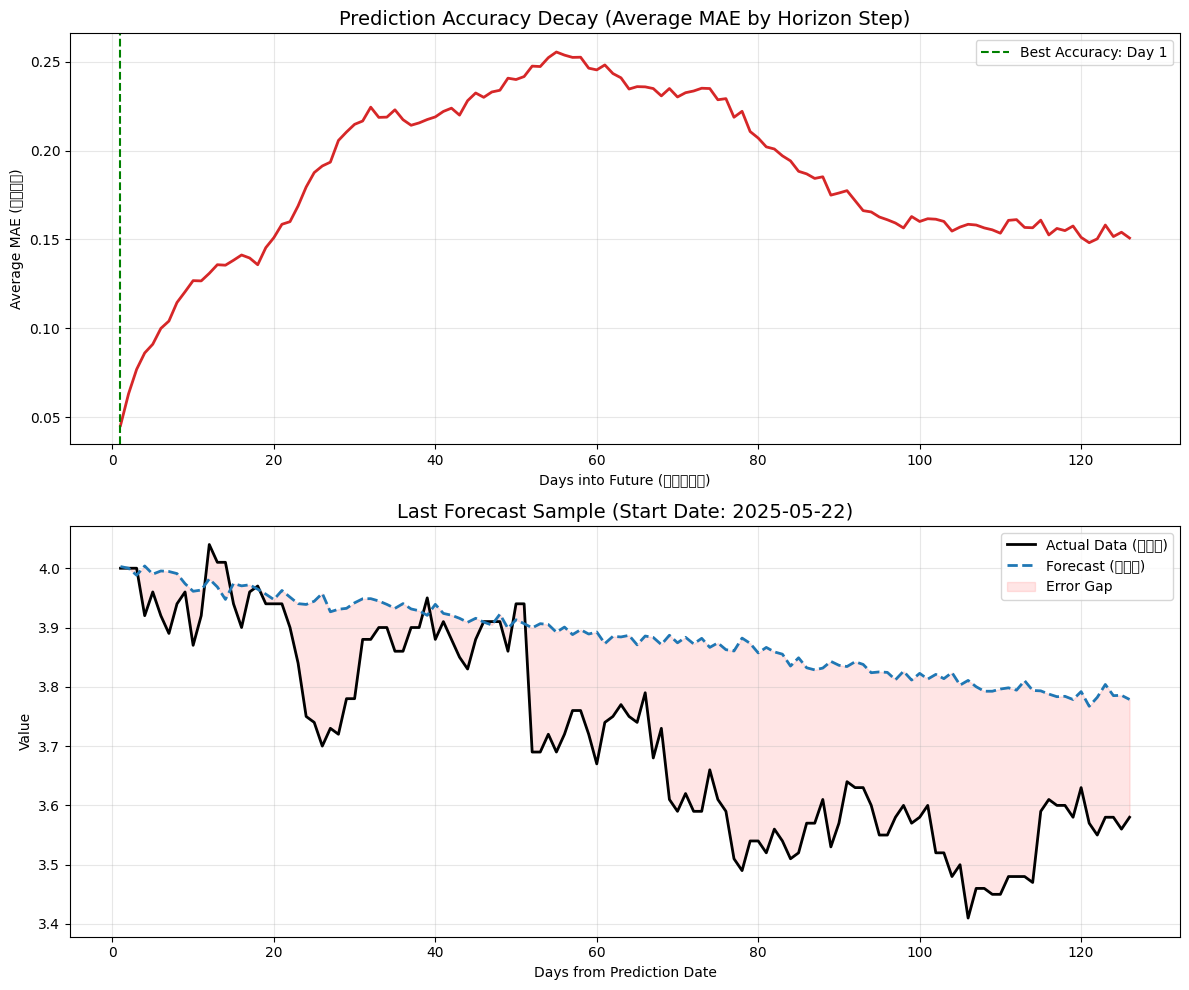


【回測報告】
總測試天數: 102
分析顯示：模型在預測「未來第 1 天」時準確度最高。


In [9]:
import pandas as pd
import numpy as np
import torch
import timesfm
import matplotlib.pyplot as plt
from pandas_datareader import data as pdr
from tqdm import tqdm
from datetime import timedelta
import os

# ==========================================
# 1. 實驗參數配置 (Configuration)
# ==========================================

# 核心目標 (你要預測的變數)
TARGET_CONFIG = {
    'source': 'fred', 
    'ticker': 'DGS2',   # 2年期美債殖利率
    'name': 'Target'
}

# 外生變數配置 (這裡放入你的 CSV)
EXOG_CONFIGS = [
    {
        'source': 'csv', 
        'path': 'FOMC_TimesFM_Ready.csv', 
        'col_to_use': 'Score',      # CSV 裡的欄位名稱
        'name': 'FOMC_Sentiment'    # 載入後的新名稱
    },
    # 你可以隨時在這裡增加新的變數，例如 FRED 的利差
    {
        'source': 'fred', 
        'ticker': 'T10Y2Y', 
        'name': 'Yield_Spread'
    }
]

# 時間設定
DATA_START = '2010-01-01'
DATA_END = '2025-11-15'   # 抓取較長的時間以包含 Ground Truth
TEST_START = '2025-01-01' # 真正開始回測的日期
FORECAST_MONTHS = 6
HORIZON_LEN = 21 * FORECAST_MONTHS # 約 126 天

# ==========================================
# 2. 智慧型資料載入器 (Data Loader)
# ==========================================

class SmartDataLoader:
    def __init__(self, start, end):
        self.start = start
        self.end = end
    
    def load(self, target_conf, exog_confs):
        print(f"正在讀取主目標: {target_conf['ticker']} ...")
        # 1. 讀取 Target (作為主索引，確保是交易日)
        main_df = self._fetch(target_conf)
        
        # 2. 迴圈讀取並合併外生變數
        for conf in exog_confs:
            try:
                print(f" -> 載入外生變數: {conf['name']}")
                exog_df = self._fetch(conf)
                # Left Join: 確保只保留主目標存在的交易日 (過濾掉週末/假日)
                main_df = main_df.join(exog_df, how='left')
            except Exception as e:
                print(f"    ⚠️ 警告: 變數 {conf.get('name')} 讀取失敗 ({e})，將跳過。")
        
        # 3. 補值: 使用 Forward Fill (模擬真實世界：無新消息時沿用舊數據)
        return main_df.ffill().dropna()

    def _fetch(self, conf):
        if conf['source'] == 'fred':
            df = pdr.get_data_fred(conf['ticker'], start=self.start, end=self.end)
            df.columns = [conf['name']]
            return df
            
        elif conf['source'] == 'csv':
            if not os.path.exists(conf['path']):
                print(f"錯誤: 找不到檔案 {conf['path']}")
                return pd.DataFrame()
            
            df = pd.read_csv(conf['path'])
            # 自動搜尋日期欄位
            date_col = next((c for c in df.columns if 'date' in c.lower()), None)
            if date_col:
                df[date_col] = pd.to_datetime(df[date_col])
                df.set_index(date_col, inplace=True)
                # 取出指定欄位
                col = conf.get('col_to_use', df.columns[0])
                if col in df.columns:
                    return df[[col]].rename(columns={col: conf['name']})
            return pd.DataFrame()
        return pd.DataFrame()

# 執行資料載入
loader = SmartDataLoader(DATA_START, DATA_END)
df_merged = loader.load(TARGET_CONFIG, EXOG_CONFIGS)
print(f"資料準備完成，總筆數: {len(df_merged)}")

# ==========================================
# 3. 初始化 TimesFM 模型 (GPU)
# ==========================================

print(f"\n--- 初始化 TimesFM (GPU: {torch.cuda.get_device_name(0)}) ---")
tfm = timesfm.TimesFM_2p5_200M_torch.from_pretrained(
    "google/timesfm-2.5-200m-pytorch",
    device="cuda",
    torch_compile=True
)

config = timesfm.ForecastConfig(
    max_context=4096, 
    max_horizon=HORIZON_LEN + 20, 
    normalize_inputs=True,
)
tfm.compile(config)

# ==========================================
# 4. 滾動回測迴圈 (Rolling Forecast Loop)
# ==========================================

results = []
errors_by_step = [] # 存每一天的誤差 (用於期限結構分析)
last_run_data = {}  # 存最後一次的詳細數據 (用於繪圖)

# 產生測試日期列表 (只包含資料中有的交易日)
test_dates = [d for d in pd.date_range(TEST_START, df_merged.index[-HORIZON_LEN-1], freq='B') if d in df_merged.index]

print(f"開始滾動回測... (共 {len(test_dates)} 個測試點)")

for current_date in tqdm(test_dates, desc="Rolling Forecast"):
    
    # [1] 準備 Context (防偷看: 嚴格取到 current_date 之前一天)
    # 目前模型是 Univariate，所以只取 Target 的歷史
    past_data = df_merged.loc[:current_date - timedelta(days=1)]
    context = past_data[TARGET_CONFIG['name']].values.astype(np.float32)
    
    # [2] 準備 Ground Truth (未來解答)
    future_truth = df_merged.loc[current_date:].head(HORIZON_LEN)[TARGET_CONFIG['name']].values
    
    # 如果剩餘資料不足預測長度，就停止
    if len(future_truth) < HORIZON_LEN: 
        break

    try:
        # [3] 執行預測
        forecast_result = tfm.forecast(inputs=[context], horizon=HORIZON_LEN)
        
        # --- [關鍵修正] 維度形狀處理邏輯 ---
        # 步驟 A: 處理 Tuple 回傳
        if isinstance(forecast_result, tuple):
            forecast_result = forecast_result[0]
            
        # 步驟 B: 取出 Batch 0 (我們只傳入一筆 context)
        # 結果可能是 (126,) 或 (126, 10)
        batch_pred = forecast_result[0] 
        
        # 步驟 C: 處理分位數
        # 若有多維 (例如包含 quantile)，取第 0 欄 (通常是 Mean)
        # 若是一維，直接使用
        if batch_pred.ndim > 1:
            pred = batch_pred[:, 0]
        else:
            pred = batch_pred
        # ------------------------------------

        # 確保長度對齊
        pred = pred[:len(future_truth)]

        # [4] 計算誤差
        mae = np.mean(np.abs(pred - future_truth))
        rmse = np.sqrt(np.mean((pred - future_truth)**2))
        
        results.append({'Date': current_date, 'MAE': mae, 'RMSE': rmse})
        
        # 存下逐日誤差 (Vector)
        step_error = np.abs(pred - future_truth)
        errors_by_step.append(step_error)
        
        # 暫存最後一次資料
        last_run_data = {'pred': pred, 'truth': future_truth, 'date': current_date}

    except Exception as e:
        print(f"\nError on {current_date}: {e}")

# ==========================================
# 5. 分析與視覺化
# ==========================================

if results:
    # --- 圖表 1: 預測準確度期限結構 (多久會準?) ---
    if errors_by_step:
        # 將所有誤差堆疊取平均
        avg_error_curve = np.mean(np.vstack(errors_by_step), axis=0)
        
        plt.figure(figsize=(12, 10))
        
        plt.subplot(2, 1, 1)
        plt.plot(range(1, len(avg_error_curve)+1), avg_error_curve, color='#d62728', linewidth=2)
        plt.title('Prediction Accuracy Decay (Average MAE by Horizon Step)', fontsize=14)
        plt.xlabel('Days into Future (未來第幾天)')
        plt.ylabel('Average MAE (平均誤差)')
        plt.grid(True, alpha=0.3)
        
        # 標記最佳預測點
        best_day = np.argmin(avg_error_curve) + 1
        plt.axvline(best_day, color='green', linestyle='--', label=f'Best Accuracy: Day {best_day}')
        plt.legend()

    # --- 圖表 2: 最後一次預測 vs 實際走勢 ---
    if last_run_data:
        plt.subplot(2, 1, 2)
        days_axis = range(1, len(last_run_data['pred'])+1)
        plt.plot(days_axis, last_run_data['truth'], label='Actual Data (實際值)', color='black', linewidth=2)
        plt.plot(days_axis, last_run_data['pred'], label='Forecast (預測值)', color='#1f77b4', linestyle='--', linewidth=2)
        
        # 畫出誤差陰影
        plt.fill_between(days_axis, last_run_data['truth'], last_run_data['pred'], color='red', alpha=0.1, label='Error Gap')
        
        date_str = last_run_data['date'].strftime('%Y-%m-%d')
        plt.title(f'Last Forecast Sample (Start Date: {date_str})', fontsize=14)
        plt.xlabel('Days from Prediction Date')
        plt.ylabel('Value')
        plt.legend()
        plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"\n【回測報告】")
    print(f"總測試天數: {len(results)}")
    if 'best_day' in locals():
        print(f"分析顯示：模型在預測「未來第 {best_day} 天」時準確度最高。")
else:
    print("沒有產生有效的回測結果，請檢查資料或模型設定。")

In [17]:
import pandas as pd
import numpy as np
import torch
import timesfm
import matplotlib.pyplot as plt
from pandas_datareader import data as pdr
from tqdm import tqdm
from datetime import timedelta
import os

# ==========================================
# 1. 實驗配置 (智慧修正版)
# ==========================================

# 既然檔案在當前目錄，直接寫檔名即可
CSV_FILENAME = 'FOMC_TimesFM_Ready.csv'

# 設定回測區間：2023-2024 (這樣我們才有 Ground Truth 來畫準確度圖)
TEST_START = '2023-01-01' 

DATA_START = '2010-01-01'
DATA_END = '2025-12-31'
FORECAST_MONTHS = 12
HORIZON_LEN = 21 * FORECAST_MONTHS # 預測 1 年 (約 252 天)

# 核心目標
TARGET_CONFIG = {'source': 'fred', 'ticker': 'DGS2', 'name': 'Target'}

# 外生變數清單
EXOG_CONFIGS = [
    # 1. 情緒變數 (智慧偵測欄位)
    {
        'source': 'csv',
        'path': CSV_FILENAME,
        'col_to_use': ['Net_Score', 'Score', 'Sentiment'], # 讓它自動去試這幾個名字
        'name': 'FOMC_Sentiment',
        'fill_method': 'zero'
    },
    # 2. 總經變數
    {'source': 'fred', 'ticker': 'CPILFESL', 'name': 'Core_CPI', 'fill_method': 'ffill'},
    {'source': 'fred', 'ticker': 'PCEPILFE', 'name': 'Core_PCE', 'fill_method': 'ffill'},
    {'source': 'fred', 'ticker': 'UNRATE', 'name': 'Unemployment_Rate', 'fill_method': 'ffill'},
    {
        'source': 'fred', 'ticker': 'CES0500000003', 'name': 'Hourly_Earnings_YoY', 'fill_method': 'ffill',
        'transform': lambda x: x.pct_change(12) * 100 
    }
]

# ==========================================
# 2. 堅固型資料載入器 (Explicit Error Reporting)
# ==========================================

class RobustDataLoader:
    def __init__(self, start, end):
        self.start = start
        self.end = end
    
    def load(self, target_conf, exog_confs):
        print(f"正在讀取主目標: {target_conf['ticker']} ...")
        try:
            main_df = self._fetch(target_conf)
        except Exception as e:
            raise ValueError(f"無法下載目標變數，請檢查網路。錯誤: {e}")
            
        if main_df.empty:
            raise ValueError("目標變數為空，程式停止。")

        exog_dfs = []
        fill_strategies = {}

        for conf in exog_confs:
            print(f" -> 載入外生變數: {conf['name']}")
            try:
                df = self._fetch(conf)
                
                # --- 詳細錯誤診斷 ---
                if df.empty:
                    if conf['source'] == 'csv':
                        print(f"    ❌ 失敗: CSV 讀取後為空。可能原因：路徑錯誤、日期格式不符、或檔案損壞。")
                        # 嘗試列出當前目錄檔案幫忙除錯
                        print(f"    (當前目錄檔案: {os.listdir('.')[:5]}...)")
                    else:
                        print(f"    ❌ 失敗: FRED 下載回傳空值。")
                    continue
                # -------------------

                if 'transform' in conf:
                    df = df.apply(conf['transform'])
                
                exog_dfs.append(df)
                fill_strategies[conf['name']] = conf.get('fill_method', 'ffill')
                print(f"    ✅ 成功載入 (筆數: {len(df)})")
                
            except Exception as e:
                print(f"    ⚠️ 發生未預期錯誤: {e}")

        # 合併
        if exog_dfs:
            for df_exog in exog_dfs:
                main_df = main_df.join(df_exog, how='left')
        
        # 補值
        valid_cols = main_df.columns
        cols_ffill = [c for c, m in fill_strategies.items() if m == 'ffill' and c in valid_cols]
        if cols_ffill: main_df[cols_ffill] = main_df[cols_ffill].ffill()
        
        cols_zero = [c for c, m in fill_strategies.items() if m == 'zero' and c in valid_cols]
        if cols_zero: main_df[cols_zero] = main_df[cols_zero].fillna(0)

        main_df.dropna(subset=[target_conf['name']], inplace=True)
        return main_df.ffill().dropna()

    def _fetch(self, conf):
        if conf['source'] == 'fred':
            try:
                df = pdr.get_data_fred(conf['ticker'], start=self.start, end=self.end)
                df.columns = [conf['name']]
                return df
            except: return pd.DataFrame()
            
        elif conf['source'] == 'csv':
            path = conf.get('path', '')
            # 自動搜尋機制
            if not os.path.exists(path):
                if os.path.exists(os.path.basename(path)):
                    path = os.path.basename(path)
                else:
                    print(f"    Debug: 找不到檔案路徑 '{path}'")
                    return pd.DataFrame()
            
            try:
                # 嘗試讀取
                df = pd.read_csv(path)
                
                # 1. 智慧找日期
                date_col = next((c for c in df.columns if 'date' in c.lower()), None)
                if not date_col:
                    print(f"    Debug: CSV 中找不到含有 'date' 字樣的欄位。現有欄位: {df.columns.tolist()}")
                    return pd.DataFrame()
                
                df[date_col] = pd.to_datetime(df[date_col])
                df.set_index(date_col, inplace=True)
                
                # 2. 智慧找分數欄位 (支援多選)
                possible_cols = conf.get('col_to_use')
                if isinstance(possible_cols, str): possible_cols = [possible_cols]
                
                target_col = None
                for col in possible_cols:
                    if col in df.columns:
                        target_col = col
                        break
                
                if target_col:
                    return df[[target_col]].rename(columns={target_col: conf['name']})
                else:
                    print(f"    Debug: 找不到目標欄位 {possible_cols}。CSV 現有欄位: {df.columns.tolist()}")
                    return pd.DataFrame()
                    
            except Exception as e:
                print(f"    Debug: CSV 解析過程發生錯誤: {e}")
                return pd.DataFrame()
                
        return pd.DataFrame()

# 載入資料
loader = RobustDataLoader(DATA_START, DATA_END)
df_merged = loader.load(TARGET_CONFIG, EXOG_CONFIGS)
print(f"資料準備完成，總筆數: {len(df_merged)}")

# ==========================================
# 3. 初始化 TimesFM
# ==========================================

print(f"\n--- 初始化 TimesFM (GPU: {torch.cuda.get_device_name(0)}) ---")
tfm = timesfm.TimesFM_2p5_200M_torch.from_pretrained(
    "google/timesfm-2.5-200m-pytorch",
    device="cuda",
    torch_compile=True
)
config = timesfm.ForecastConfig(max_context=4096, max_horizon=HORIZON_LEN + 30, normalize_inputs=True)
tfm.compile(config)

# ==========================================
# 4. 滾動回測 (Backtesting)
# ==========================================

results = []
errors_by_step = []
best_run_mae = float('inf')
best_run_data = {}
last_run_data = {}

test_dates = [d for d in pd.date_range(TEST_START, df_merged.index[-HORIZON_LEN-1], freq='B') if d in df_merged.index]

print(f"開始滾動回測 2023-2024 (預計 {len(test_dates)} 次)...")

for current_date in tqdm(test_dates, desc="Forecasting"):
    
    # Context & Truth
    past_data = df_merged.loc[:current_date - timedelta(days=1)]
    context = past_data[TARGET_CONFIG['name']].values.astype(np.float32)
    future_truth = df_merged.loc[current_date:].head(HORIZON_LEN)[TARGET_CONFIG['name']].values
    
    if len(future_truth) < HORIZON_LEN: break

    try:
        forecast_result = tfm.forecast(inputs=[context], horizon=HORIZON_LEN)
        
        # 維度處理
        if isinstance(forecast_result, tuple): forecast_result = forecast_result[0]
        batch_pred = forecast_result[0]
        if batch_pred.ndim > 1: pred = batch_pred[:, 0]
        else: pred = batch_pred
        
        pred = pred[:len(future_truth)]

        mae = np.mean(np.abs(pred - future_truth))
        results.append({'Date': current_date, 'MAE': mae})
        errors_by_step.append(np.abs(pred - future_truth))
        
        last_run_data = {'pred': pred, 'truth': future_truth, 'date': current_date}
        
        if mae < best_run_mae:
            best_run_mae = mae
            best_run_data = {'pred': pred.copy(), 'truth': future_truth.copy(), 'date': current_date, 'mae': mae}

    except Exception as e:
        print(f"Error: {e}")

# ==========================================
# 5. 視覺化
# ==========================================
# 設定中文字體
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei'] 
plt.rcParams['axes.unicode_minus'] = False 

if results:
    fig, axes = plt.subplots(3, 1, figsize=(12, 18))
    
    # 1. 期限結構
    if errors_by_step:
        avg_error_curve = np.mean(np.vstack(errors_by_step), axis=0)
        best_day = np.argmin(avg_error_curve) + 1
        axes[0].plot(range(1, len(avg_error_curve)+1), avg_error_curve, color='#d62728', linewidth=2)
        axes[0].axvline(best_day, color='green', linestyle='--', label=f'最準天數: {best_day}')
        axes[0].set_title('準確度衰退曲線 (12個月)')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

    # 2. 最佳預測
    if best_run_data:
        days = range(1, len(best_run_data['pred'])+1)
        d_str = best_run_data['date'].strftime('%Y-%m-%d')
        axes[1].plot(days, best_run_data['truth'], label='實際行情', color='black', linewidth=2)
        axes[1].plot(days, best_run_data['pred'], label='模型預測', color='#2ca02c', linestyle='--', linewidth=2)
        axes[1].fill_between(days, best_run_data['truth'], best_run_data['pred'], color='#2ca02c', alpha=0.1)
        axes[1].set_title(f'👑 史上最佳預測 (日期: {d_str}, MAE: {best_run_data["mae"]:.4f})')
        axes[1].legend()

    # 3. 最後一次預測
    if last_run_data:
        days = range(1, len(last_run_data['pred'])+1)
        d_str = last_run_data['date'].strftime('%Y-%m-%d')
        axes[2].plot(days, last_run_data['truth'], label='實際行情', color='black', linewidth=2)
        axes[2].plot(days, last_run_data['pred'], label='模型預測', color='#1f77b4', linestyle='--', linewidth=2)
        axes[2].set_title(f'最後一次預測 (日期: {d_str})')
        axes[2].legend()

    plt.tight_layout()
    plt.show()
else:
    print("無結果。")

正在讀取主目標: DGS2 ...
 -> 載入外生變數: FOMC_Sentiment
    Debug: CSV 中找不到含有 'date' 字樣的欄位。現有欄位: ['unique_id', 'ds', 'y']
    ❌ 失敗: CSV 讀取後為空。可能原因：路徑錯誤、日期格式不符、或檔案損壞。
    (當前目錄檔案: ['.ipynb_checkpoints', 'fed_transcripts_structured_pycharm.csv', 'FOMCpresconf20190130.pdf', 'fomc_analysis.ipynb', 'FOMC_TimesFM_Ready.csv']...)
 -> 載入外生變數: Core_CPI
    ✅ 成功載入 (筆數: 189)
 -> 載入外生變數: Core_PCE
    ✅ 成功載入 (筆數: 188)
 -> 載入外生變數: Unemployment_Rate
    ✅ 成功載入 (筆數: 189)
 -> 載入外生變數: Hourly_Earnings_YoY
    ✅ 成功載入 (筆數: 189)
資料準備完成，總筆數: 3709

--- 初始化 TimesFM (GPU: NVIDIA GeForce RTX 5060 Ti) ---
Downloaded.
Compiling model...
開始滾動回測 2023-2024 (預計 476 次)...


Forecasting:  27%|██▋       | 128/476 [00:47<02:08,  2.71it/s]


KeyboardInterrupt: 

In [16]:
import os

# 1. 告訴我現在 Python 站在哪裡？
current_dir = os.getcwd()
print(f"📍 Python 目前的工作目錄: {current_dir}")

# 2. 告訴我這裡面有什麼檔案？
files = os.listdir(current_dir)
print(f"📂 這裡面有的檔案: {files}")

# 3. 檢查我們想找的檔案在不在裡面
target_file_1 = 'FOMC_TimesFM_Ready.csv'
target_file_2 = 'FOMC_daily_score_only2.csv'

if target_file_1 in files:
    print(f"✅ 找到了: {target_file_1}")
elif target_file_2 in files:
    print(f"✅ 找到了: {target_file_2} (原來是這個名字！)")
else:
    print(f"❌ 通通找不到。請把 CSV 檔案複製到: {current_dir}")

📍 Python 目前的工作目錄: C:\Users\user\Desktop\llmcourse
📂 這裡面有的檔案: ['.ipynb_checkpoints', 'fed_transcripts_structured_pycharm.csv', 'FOMCpresconf20190130.pdf', 'fomc_analysis.ipynb', 'FOMC_TimesFM_Ready.csv', 'Mistral-Nemo-Instruct-2407-Q4_K_M.gguf', 'Untitled1.ipynb', 'Untitled4.ipynb']
✅ 找到了: FOMC_TimesFM_Ready.csv
